# Exploration des données foudre — Meteorage
Analyse du fichier `segment_alerts_all_airports_train.csv`

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.spatial import ConvexHull
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import time

# ── Chemins ───────────────────────────────────────────────────────────
RAW_PATH     = "segment_alerts_all_airports_train.parquet"
SILENCE_PATH = "../output/silence_dataset.parquet"
LRE_DIST     = 3.0

# ── Données brutes ────────────────────────────────────────────────────
print("Chargement df_raw...")
t0 = time.time()
df_raw = pd.read_parquet(RAW_PATH)
df_raw["date"] = pd.to_datetime(df_raw["date"], utc=True)
df_raw["type"] = np.where(df_raw["icloud"].fillna(False), "IC", "CG")
df_raw["zone"] = np.where(df_raw["dist"] < 20, "inner", "outer")
print(f"  df_raw : {df_raw.shape} — {time.time()-t0:.1f}s")

# ── Silence dataset ───────────────────────────────────────────────────
print("Chargement df_silence...")
t0 = time.time()
df_silence = pd.read_parquet(SILENCE_PATH)
df_silence["decision_time"] = pd.to_datetime(df_silence["decision_time"], utc=True)
df_silence["min_since_cg"]  = df_silence["minutes_since_reference_cg"].round(0).astype(int)
print(f"  df_silence : {df_silence.shape} — {time.time()-t0:.1f}s")

print("\nChargement terminé ✓")

Chargement df_raw...
  df_raw : (695246, 15) — 0.3s
Chargement df_silence...
  df_silence : (57461, 74) — 0.0s

Chargement terminé ✓


In [5]:
# Chunk 2
print(f"Nombre de lignes    : {len(df_raw):,}")
print(f"Nombre de colonnes  : {df_raw.shape[1]}")
print(f"\nColonnes : {list(df_raw.columns)}")

Nombre de lignes    : 695,246
Nombre de colonnes  : 15

Colonnes : ['lightning_id', 'lightning_airport_id', 'date', 'lon', 'lat', 'amplitude', 'maxis', 'icloud', 'dist', 'azimuth', 'airport', 'airport_alert_id', 'is_last_lightning_cloud_ground', 'type', 'zone']


## 1. Import des données

In [6]:
# Chunk 3
df_raw.dtypes

lightning_id                                    int64
lightning_airport_id                            int64
date                              datetime64[ns, UTC]
lon                                           float64
lat                                           float64
amplitude                                     float64
maxis                                         float64
icloud                                           bool
dist                                          float64
azimuth                                       float64
airport                                        object
airport_alert_id                              float64
is_last_lightning_cloud_ground                 object
type                                           object
zone                                           object
dtype: object

## 2. Aperçu général

In [7]:
# Chunk 4
df_raw.head()

,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,airport,airport_alert_id,is_last_lightning_cloud_ground,type,zone
0,1,1,2016-01-02 14:53:36+00:00,9.0559,42.0826,-9.90,0.3,False,27.360653,57.852343,Ajaccio,NaN,None,CG,outer
1,2,2,2016-01-02 14:53:36+00:00,9.0236,42.0953,-3.33,0.2,True,26.383167,52.117828,Ajaccio,NaN,None,IC,outer
2,3,3,2016-01-02 21:22:53+00:00,8.8585,42.0456,-18.68,0.4,True,14.313391,24.500543,Ajaccio,NaN,None,IC,inner
3,4,4,2016-01-02 21:22:53+00:00,8.8517,42.0517,-7.51,0.2,False,14.794117,20.854458,Ajaccio,1.0,False,CG,inner
4,5,5,2016-01-02 21:24:46+00:00,8.8728,42.0494,-6.01,0.2,False,15.124224,29.058471,Ajaccio,1.0,False,CG,inner


In [10]:
# Chunk 5
missing = pd.DataFrame({
    'nb_manquants':      df_raw.isnull().sum(),
    'pct_manquants (%)': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
}).sort_values('pct_manquants (%)', ascending=False)
print(missing.to_string())

                                nb_manquants  pct_manquants (%)
is_last_lightning_cloud_ground        620637              89.27
airport_alert_id                      620637              89.27
lightning_id                               0               0.00
lon                                        0               0.00
lat                                        0               0.00
lightning_airport_id                       0               0.00
date                                       0               0.00
maxis                                      0               0.00
amplitude                                  0               0.00
icloud                                     0               0.00
dist                                       0               0.00
airport                                    0               0.00
azimuth                                    0               0.00
type                                       0               0.00
zone                                    

In [11]:
# Chunk 6
df_raw.describe(include='all')

,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,airport,airport_alert_id,is_last_lightning_cloud_ground,type,zone
count,695246.000000,695246.000000,695246,695246.000000,695246.000000,695246.000000,695246.000000,695246,695246.000000,695246.000000,695246,74609.000000,74609,695246,695246
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,5,NaN,2,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,Pise,NaN,False,IC,outer
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,523066,NaN,NaN,223238,NaN,70901,523066,394562
mean,347623.500000,83670.490188,2020-09-21 22:00:37.270142720+00:00,6.369089,43.334346,-2.147851,0.973658,NaN,20.232686,172.737619,NaN,420.624817,NaN,NaN,NaN
min,1.000000,1.000000,2016-01-02 01:10:41+00:00,-2.006800,41.654100,-429.500000,0.016000,NaN,0.019786,0.000000,NaN,1.000000,NaN,NaN,NaN
25%,173812.250000,34763.000000,2018-06-03 14:12:12.249999872+00:00,-1.303500,42.497900,-5.510000,0.110000,NaN,15.311286,88.061800,NaN,203.000000,NaN,NaN,NaN
50%,347623.500000,75832.000000,2020-06-25 18:51:11.500000+00:00,9.348700,43.449600,-1.460000,0.220000,NaN,21.510229,164.334146,NaN,387.000000,NaN,NaN,NaN
75%,521434.750000,127768.750000,2023-06-17 16:29:49.750000128+00:00,10.213900,43.667900,4.600000,1.360000,NaN,26.171897,256.589120,NaN,638.000000,NaN,NaN,NaN
max,695246.000000,223238.000000,2025-12-26 01:08:02+00:00,10.771700,47.422600,584.200000,6.900000,NaN,29.999996,359.978581,NaN,1044.000000,NaN,NaN,NaN


## 3. Valeurs manquantes

In [12]:
# Chunk 7
bins   = [0, 20, 30, float('inf')]
labels = ['< 20 km', '20-30 km', '> 30 km']
dist_cat = pd.cut(df_raw['dist'], bins=bins, labels=labels)
result = dist_cat.value_counts().sort_index().to_frame(name='nb_eclairs')
result['pct (%)'] = (result['nb_eclairs'] / len(df_raw) * 100).round(2)
result

,nb_eclairs,pct (%)
dist,,
< 20 km,300684,43.25
20-30 km,394562,56.75
> 30 km,0,0.00


## 4. Statistiques descriptives

In [13]:
# Chunk 8
print("=== Type d'éclair ===")
type_result = df_raw['icloud'].value_counts().to_frame(name='nb_eclairs')
type_result.index = ['Intra-nuage (True)', 'Nuage-sol (False)']
type_result['pct (%)'] = (type_result['nb_eclairs'] / len(df_raw) * 100).round(2)
print(type_result)

=== Type d'éclair ===
                    nb_eclairs  pct (%)
Intra-nuage (True)      523066    75.23
Nuage-sol (False)       172180    24.77


In [14]:
# Chunk 9
print("\n=== Croisement distance x type ===")
bins   = [0, 20, 30, float('inf')]
labels = ['< 20 km', '20-30 km', '> 30 km']
dist_cat = pd.cut(df_raw['dist'], bins=bins, labels=labels)
cross = pd.crosstab(dist_cat, df_raw['icloud'], margins=True)
cross.columns = ['Nuage-sol', 'Intra-nuage', 'Total']
cross['pct_nuage_sol (%)']   = (cross['Nuage-sol']   / cross['Total'] * 100).round(2)
cross['pct_intra_nuage (%)'] = (cross['Intra-nuage'] / cross['Total'] * 100).round(2)
cross


=== Croisement distance x type ===


,Nuage-sol,Intra-nuage,Total,pct_nuage_sol (%),pct_intra_nuage (%)
dist,,,,,
< 20 km,74609,226075,300684,24.81,75.19
20-30 km,97571,296991,394562,24.73,75.27
All,172180,523066,695246,24.77,75.23


In [15]:
# Chunk 10
alerts = df_raw[df_raw['airport_alert_id'].notna()].copy()
duree  = alerts.groupby(['airport', 'airport_alert_id'])['date'].agg(debut='min', fin='max')
duree['duree_minutes'] = (duree['fin'] - duree['debut']).dt.total_seconds() / 60

print(f"Durée médiane d'une alerte : {duree['duree_minutes'].median():.2f} minutes")
print(f"Durée moyenne              : {duree['duree_minutes'].mean():.2f} minutes")
print(f"Durée min                  : {duree['duree_minutes'].min():.2f} minutes")
print(f"Durée max                  : {duree['duree_minutes'].max():.2f} minutes")

Durée médiane d'une alerte : 9.58 minutes
Durée moyenne              : 29.86 minutes
Durée min                  : 0.00 minutes
Durée max                  : 578.72 minutes


In [16]:
# Chunk 11
nb_alertes = df_raw.groupby(['airport', 'airport_alert_id']).ngroups
print(f"Nombre d'alertes orageuses : {nb_alertes}")
print(df_raw.groupby("airport")["airport_alert_id"].nunique())

Nombre d'alertes orageuses : 3708
airport
Ajaccio      733
Bastia       795
Biarritz     832
Nantes       304
Pise        1044
Name: airport_alert_id, dtype: int64


In [17]:
# Chunk 12 — reconstruction df_alerts depuis df_raw
df_alerts = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .groupby(["airport", "airport_alert_id"])["date"]
    .agg(t_start="min", t_end="max")
    .reset_index()
)
df_alerts["duration"] = (df_alerts["t_end"] - df_alerts["t_start"]).dt.total_seconds() / 60
df_alerts["hour"]     = df_alerts["t_start"].dt.hour
df_alerts["month"]    = df_alerts["t_start"].dt.month
df_alerts["season"]   = df_alerts["month"].map({
    12:"Hiver", 1:"Hiver", 2:"Hiver",
    3:"Printemps", 4:"Printemps", 5:"Printemps",
    6:"Été", 7:"Été", 8:"Été",
    9:"Automne", 10:"Automne", 11:"Automne"
})
print(f"df_alerts : {df_alerts.shape}")
print(df_alerts.head())

df_alerts : (3708, 8)
   airport  airport_alert_id                   t_start  \
0  Ajaccio               1.0 2016-01-02 21:22:53+00:00   
1  Ajaccio               2.0 2016-01-12 06:37:45+00:00   
2  Ajaccio               3.0 2016-01-12 07:25:37+00:00   
3  Ajaccio               4.0 2016-02-07 14:05:14+00:00   
4  Ajaccio               5.0 2016-02-07 14:35:39+00:00   

                      t_end  duration  hour  month season  
0 2016-01-02 21:28:54+00:00  6.016667    21      1  Hiver  
1 2016-01-12 06:37:45+00:00  0.000000     6      1  Hiver  
2 2016-01-12 07:25:37+00:00  0.000000     7      1  Hiver  
3 2016-02-07 14:05:14+00:00  0.000000    14      2  Hiver  
4 2016-02-07 14:35:39+00:00  0.000000    14      2  Hiver  


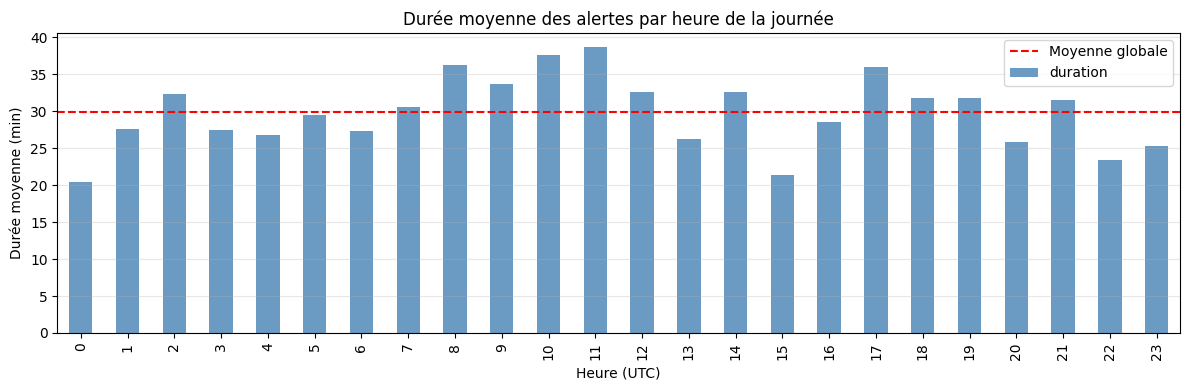

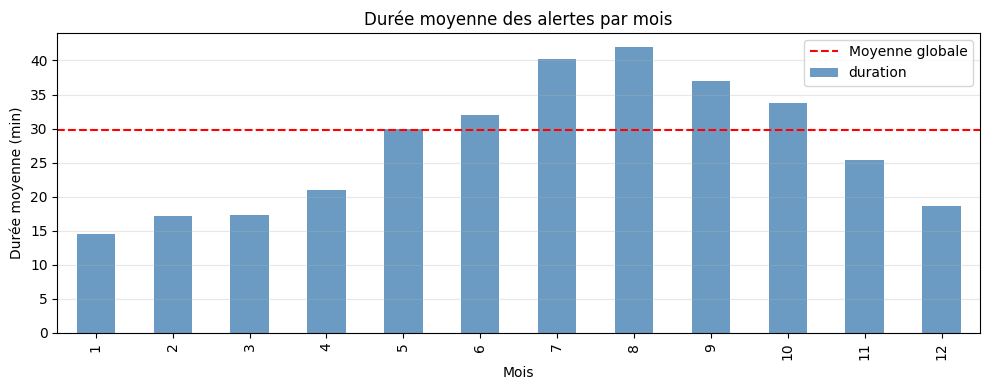

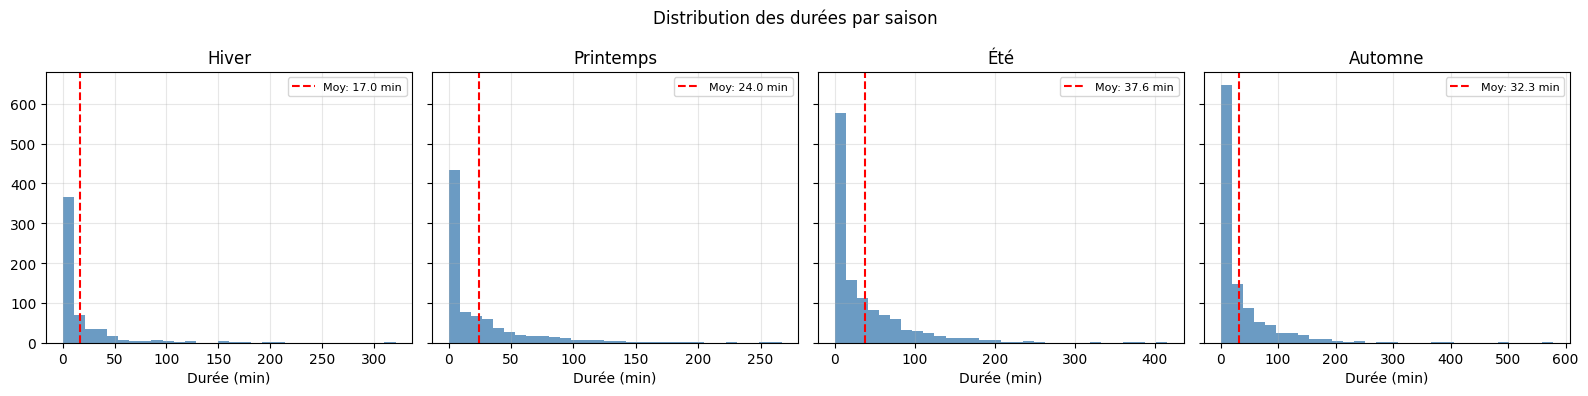

Durée moyenne par saison :
           mean  median  count
season                        
Automne    32.3     9.9   1086
Hiver      17.0     2.3    567
Printemps  24.0     6.9    826
Été        37.6    17.0   1229

Corrélation heure/durée : 0.003
Corrélation mois/durée  : 0.066


In [18]:
# Chunk 13
plt.figure(figsize=(12, 4))
df_alerts.groupby("hour")["duration"].mean().plot(kind="bar", color="steelblue", alpha=0.8)
plt.axhline(df_alerts["duration"].mean(), color="red", linestyle="--", label="Moyenne globale")
plt.title("Durée moyenne des alertes par heure de la journée")
plt.xlabel("Heure (UTC)"); plt.ylabel("Durée moyenne (min)")
plt.legend(); plt.grid(alpha=0.3, axis="y"); plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 4))
df_alerts.groupby("month")["duration"].mean().plot(kind="bar", color="steelblue", alpha=0.8)
plt.axhline(df_alerts["duration"].mean(), color="red", linestyle="--", label="Moyenne globale")
plt.title("Durée moyenne des alertes par mois")
plt.xlabel("Mois"); plt.ylabel("Durée moyenne (min)")
plt.legend(); plt.grid(alpha=0.3, axis="y"); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, saison in zip(axes, ["Hiver", "Printemps", "Été", "Automne"]):
    data = df_alerts[df_alerts["season"] == saison]["duration"]
    ax.hist(data, bins=30, color="steelblue", alpha=0.8)
    ax.axvline(data.mean(), color="red", linestyle="--", label=f"Moy: {data.mean():.1f} min")
    ax.set_title(saison); ax.set_xlabel("Durée (min)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle("Distribution des durées par saison"); plt.tight_layout(); plt.show()

print("Durée moyenne par saison :")
print(df_alerts.groupby("season")["duration"].agg(["mean", "median", "count"]).round(1))
print("\nCorrélation heure/durée :", df_alerts["hour"].corr(df_alerts["duration"]).round(3))
print("Corrélation mois/durée  :", df_alerts["month"].corr(df_alerts["duration"]).round(3))

          n_alerts  mean_duration  median_duration  std_duration
airport                                                         
Pise          1044          33.84            11.98         54.91
Bastia         795          32.73            10.50         53.64
Ajaccio        733          27.85             8.73         43.36
Nantes         304          25.92             8.55         40.77
Biarritz       832          25.36             7.43         43.53


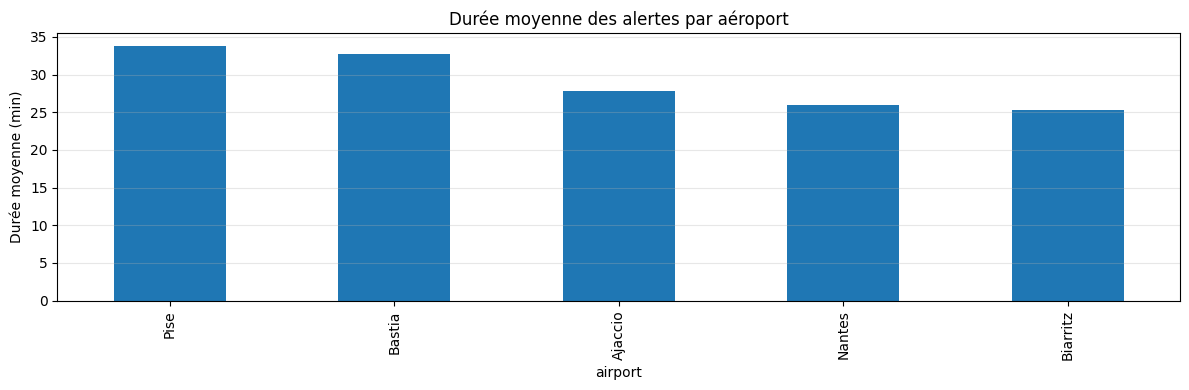

In [19]:
# Chunk 14
airport_stats = (
    df_alerts.groupby("airport")
    .agg(n_alerts=("airport_alert_id","nunique"), mean_duration=("duration","mean"),
         median_duration=("duration","median"), std_duration=("duration","std"))
    .sort_values("mean_duration", ascending=False)
)
print(airport_stats.round(2))
airport_stats["mean_duration"].plot(kind="bar", figsize=(12, 4))
plt.title("Durée moyenne des alertes par aéroport"); plt.ylabel("Durée moyenne (min)")
plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

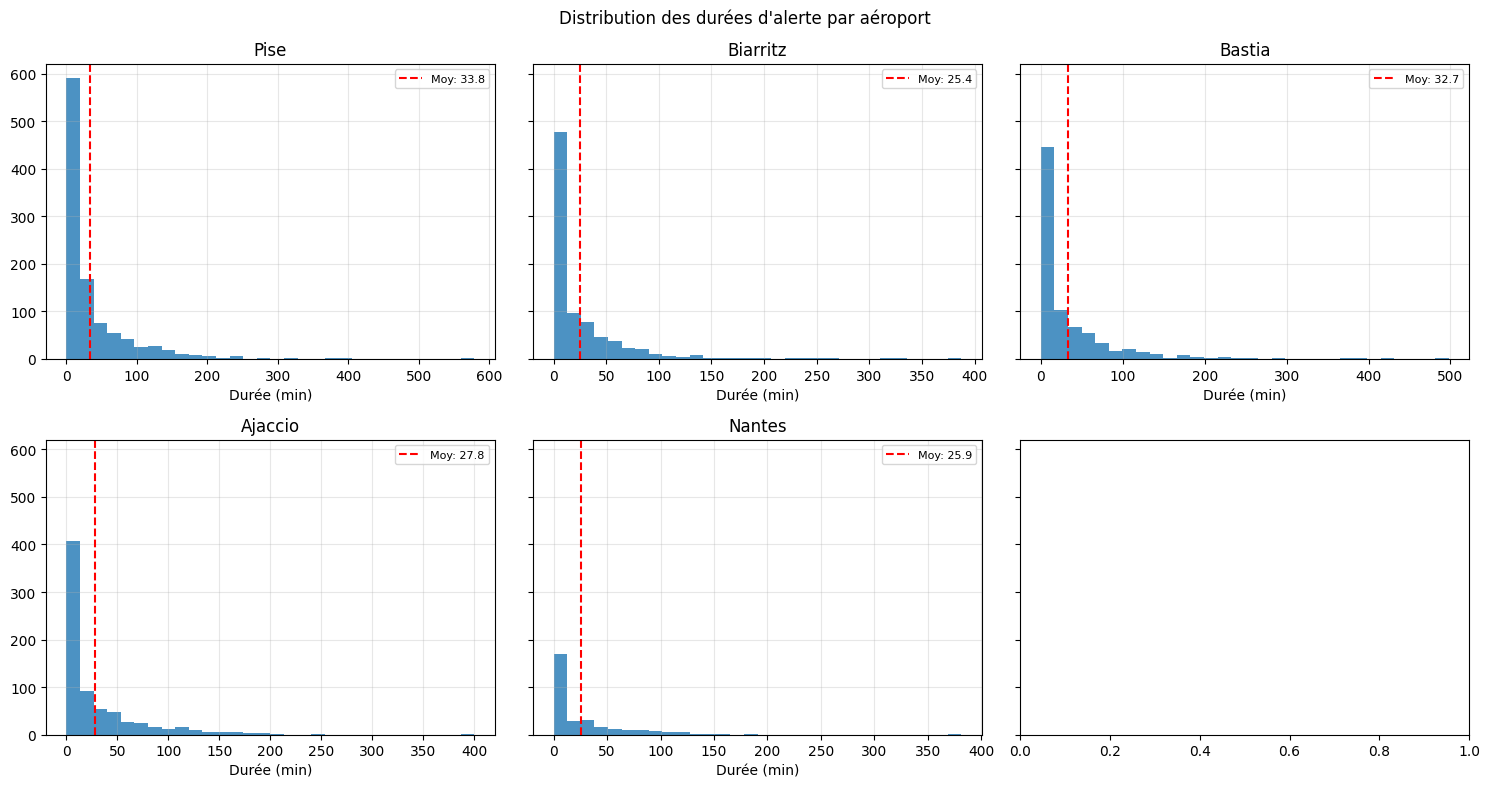

In [20]:
# Chunk 15
top_airports = df_alerts["airport"].value_counts().head(6).index
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False, sharey=True)
axes = axes.ravel()
for ax, airport in zip(axes, top_airports):
    data = df_alerts.loc[df_alerts["airport"] == airport, "duration"]
    ax.hist(data, bins=30, alpha=0.8)
    ax.axvline(data.mean(), color="red", linestyle="--", label=f"Moy: {data.mean():.1f}")
    ax.set_title(airport); ax.set_xlabel("Durée (min)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle("Distribution des durées d'alerte par aéroport"); plt.tight_layout(); plt.show()

In [22]:
# Chunk 16
CLOSE_RADIUS_KM = 3.0
close_per_alert = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .assign(is_cg_close=lambda x: (x["type"] == "CG") & (x["dist"] < CLOSE_RADIUS_KM))
    .groupby(["airport", "airport_alert_id"])["is_cg_close"]
    .max().reset_index(name="has_close_cg")
)
print("Part globale d'alertes avec au moins un CG < 3 km :")
print(f"{100 * close_per_alert['has_close_cg'].mean():.2f}%")
print("\nPar aéroport :")
print((100 * close_per_alert.groupby('airport')["has_close_cg"].mean()).round(2).sort_values(ascending=False))

Part globale d'alertes avec au moins un CG < 3 km :
12.89%

Par aéroport :
airport
Nantes      14.14
Pise        13.60
Biarritz    12.62
Ajaccio     12.55
Bastia      12.08
Name: has_close_cg, dtype: float64


               mean  median  count
has_close_cg                      
False         19.76    5.46   3230
True          98.12   79.99    478


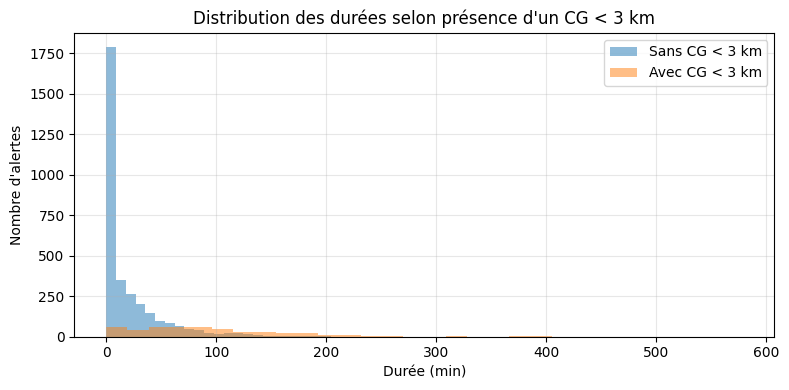

In [23]:
# Chunk 17
alert_close = df_alerts.merge(close_per_alert, on=["airport","airport_alert_id"], how="left").fillna({"has_close_cg": 0})
print(alert_close.groupby("has_close_cg")["duration"].agg(["mean","median","count"]).round(2))

plt.figure(figsize=(8, 4))
for label, val in [("Sans CG < 3 km", 0), ("Avec CG < 3 km", 1)]:
    data = alert_close.loc[alert_close["has_close_cg"] == val, "duration"].dropna()
    plt.hist(data, bins=30, alpha=0.5, label=label)
plt.title("Distribution des durées selon présence d'un CG < 3 km")
plt.xlabel("Durée (min)"); plt.ylabel("Nombre d'alertes")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

count    3708.00
mean       10.94
std         5.90
min         0.04
25%         5.86
50%        11.49
75%        16.30
max        19.99
Name: min_dist, dtype: float64


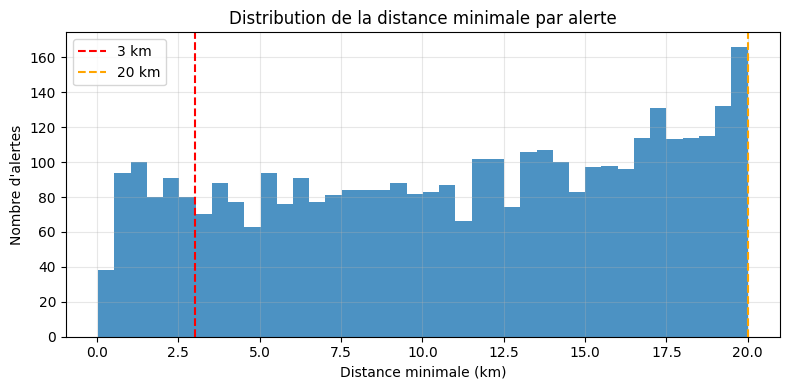

In [24]:
# Chunk 18
min_dist_per_alert = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .groupby(["airport", "airport_alert_id"])["dist"]
    .min().reset_index(name="min_dist")
)
print(min_dist_per_alert["min_dist"].describe().round(2))
plt.figure(figsize=(8, 4))
plt.hist(min_dist_per_alert["min_dist"], bins=40, alpha=0.8)
plt.axvline(3,  color="red",    linestyle="--", label="3 km")
plt.axvline(20, color="orange", linestyle="--", label="20 km")
plt.title("Distribution de la distance minimale par alerte")
plt.xlabel("Distance minimale (km)"); plt.ylabel("Nombre d'alertes")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [25]:
# Chunk 19
cg_inner_counts = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .assign(is_cg_inner=lambda x: (x["type"] == "CG") & (x["dist"] < 20))
    .groupby(["airport", "airport_alert_id"])["is_cg_inner"]
    .sum().reset_index(name="n_cg_inner")
)
close_profile = (
    close_per_alert
    .merge(cg_inner_counts, on=["airport","airport_alert_id"], how="left")
    .merge(df_alerts[["airport","airport_alert_id","duration"]], on=["airport","airport_alert_id"], how="left")
)
print(close_profile.groupby("has_close_cg")[["n_cg_inner","duration"]].agg(["mean","median"]).round(2))

             n_cg_inner        duration       
                   mean median     mean median
has_close_cg                                  
False              7.26    2.0    19.76   5.46
True             107.05   44.0    98.12  79.99


In [26]:
# Chunk 20
airport_cg       = cg_inner_counts.groupby("airport")["n_cg_inner"].agg(mean_cg_inner="mean", median_cg_inner="median").reset_index()
airport_min_dist = min_dist_per_alert.groupby("airport")["min_dist"].agg(mean_min_dist="mean", median_min_dist="median").reset_index()
airport_close    = close_per_alert.groupby("airport")["has_close_cg"].mean().reset_index(name="rate_close_cg")

airport_full = (
    df_alerts.groupby("airport").agg(
        n_alerts=("airport_alert_id","nunique"), mean_duration=("duration","mean"),
        median_duration=("duration","median"), std_duration=("duration","std")
    ).reset_index()
    .merge(airport_cg, on="airport", how="left")
    .merge(airport_min_dist, on="airport", how="left")
    .merge(airport_close, on="airport", how="left")
)
airport_full["rate_close_cg"] *= 100
print(airport_full.round(2).sort_values("mean_duration", ascending=False))

    airport  n_alerts  mean_duration  median_duration  std_duration  \
4      Pise      1044          33.84            11.98         54.91   
1    Bastia       795          32.73            10.50         53.64   
0   Ajaccio       733          27.85             8.73         43.36   
3    Nantes       304          25.92             8.55         40.77   
2  Biarritz       832          25.36             7.43         43.53   

   mean_cg_inner  median_cg_inner  mean_min_dist  median_min_dist  \
4          23.66              3.0          10.69            11.29   
1          23.09              3.0          11.27            11.93   
0          17.90              2.0          11.21            11.85   
3          17.17              2.0          10.53            10.64   
2          15.88              3.0          10.86            11.13   

   rate_close_cg  
4          13.60  
1          12.08  
0          12.55  
3          14.14  
2          12.62  


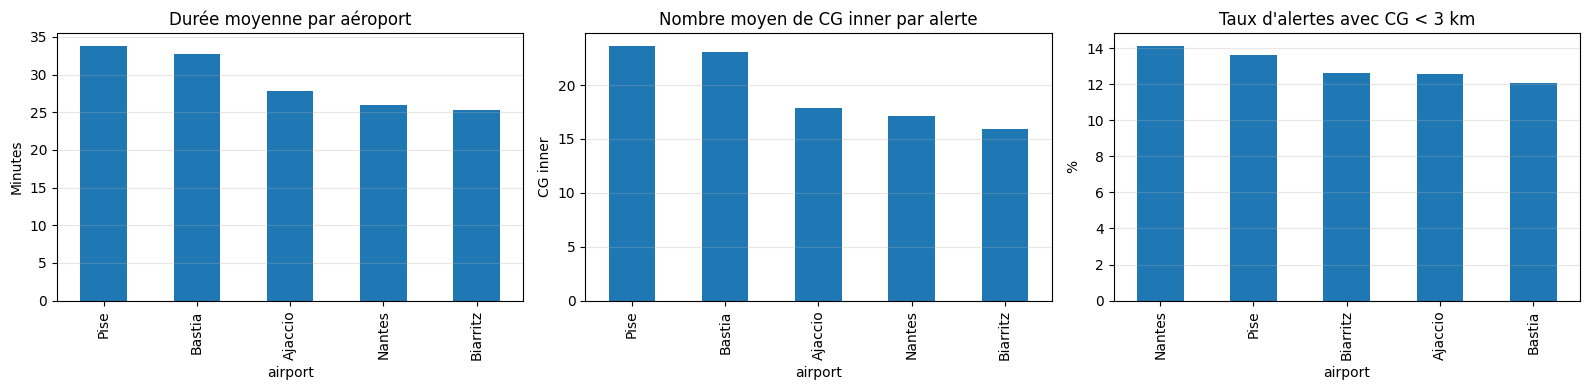

In [27]:
# Chunk 21
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
airport_full.sort_values("mean_duration", ascending=False).plot(x="airport", y="mean_duration", kind="bar", ax=axes[0], legend=False)
axes[0].set_title("Durée moyenne par aéroport"); axes[0].set_ylabel("Minutes"); axes[0].grid(axis="y", alpha=0.3)
airport_full.sort_values("mean_cg_inner", ascending=False).plot(x="airport", y="mean_cg_inner", kind="bar", ax=axes[1], legend=False)
axes[1].set_title("Nombre moyen de CG inner par alerte"); axes[1].set_ylabel("CG inner"); axes[1].grid(axis="y", alpha=0.3)
airport_full.sort_values("rate_close_cg", ascending=False).plot(x="airport", y="rate_close_cg", kind="bar", ax=axes[2], legend=False)
axes[2].set_title("Taux d'alertes avec CG < 3 km"); axes[2].set_ylabel("%"); axes[2].grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

In [30]:
# Chunk 23
type_by_airport = pd.crosstab(alert_type_df["airport"], alert_type_df["proximity_bin"], normalize="index") * 100
print(type_by_airport.round(1))

proximity_bin  <3 km  3-10 km  10-20 km
airport                                
Ajaccio         12.6     28.6      58.8
Bastia          12.1     29.6      58.4
Biarritz        12.6     32.3      55.0
Nantes          14.1     31.9      53.9
Pise            13.6     31.8      54.6


In [31]:
# Chunk 24
alert_local = alert_type_df.merge(
    df_alerts[["airport","airport_alert_id","hour","month"]],
    on=["airport","airport_alert_id"], how="left"
)
for airport, sub in alert_local.groupby("airport"):
    print(f"\n--- {airport} ---")
    print(sub[["duration","n_cg_inner","min_dist","hour","month"]].corr().round(2))


--- Ajaccio ---
            duration  n_cg_inner  min_dist  hour  month
duration        1.00        0.59     -0.59  0.03   0.04
n_cg_inner      0.59        1.00     -0.39  0.00   0.04
min_dist       -0.59       -0.39      1.00 -0.05  -0.01
hour            0.03        0.00     -0.05  1.00   0.01
month           0.04        0.04     -0.01  0.01   1.00

--- Bastia ---
            duration  n_cg_inner  min_dist  hour  month
duration        1.00        0.63     -0.57  0.01   0.08
n_cg_inner      0.63        1.00     -0.29 -0.03   0.04
min_dist       -0.57       -0.29      1.00 -0.06  -0.06
hour            0.01       -0.03     -0.06  1.00  -0.06
month           0.08        0.04     -0.06 -0.06   1.00

--- Biarritz ---
            duration  n_cg_inner  min_dist  hour  month
duration        1.00        0.64     -0.54  0.01  -0.02
n_cg_inner      0.64        1.00     -0.37  0.03  -0.03
min_dist       -0.54       -0.37      1.00  0.02   0.01
hour            0.01        0.03      0.02  1.00  -0.

In [32]:
# Chunk 25
airport_coords = {
    "Ajaccio":  {"lat": 41.9236, "lon":  8.8029},
    "Bastia":   {"lat": 42.5527, "lon":  9.4837},
    "Biarritz": {"lat": 43.4684, "lon": -1.5232},
    "Nantes":   {"lat": 47.1532, "lon": -1.6107},
    "Pise":     {"lat": 43.6839, "lon": 10.3927},
}

def compute_azimuth_from_coords(lat_e, lon_e, lat_ap, lon_ap):
    return np.degrees(np.arctan2(lon_e - lon_ap, lat_e - lat_ap)) % 360

sample = df_raw.dropna(subset=["airport_alert_id"]).head(5000).copy()
sample["lat_ap"] = sample["airport"].map(lambda a: airport_coords[a]["lat"])
sample["lon_ap"] = sample["airport"].map(lambda a: airport_coords[a]["lon"])
sample["azimuth_computed"] = compute_azimuth_from_coords(
    sample["lat"], sample["lon"], sample["lat_ap"], sample["lon_ap"]
)
corr = sample[["azimuth","azimuth_computed"]].corr().iloc[0, 1]
print(f"Corrélation azimuth brut vs azimuth recalculé : {corr:.4f}")

Corrélation azimuth brut vs azimuth recalculé : 1.0000


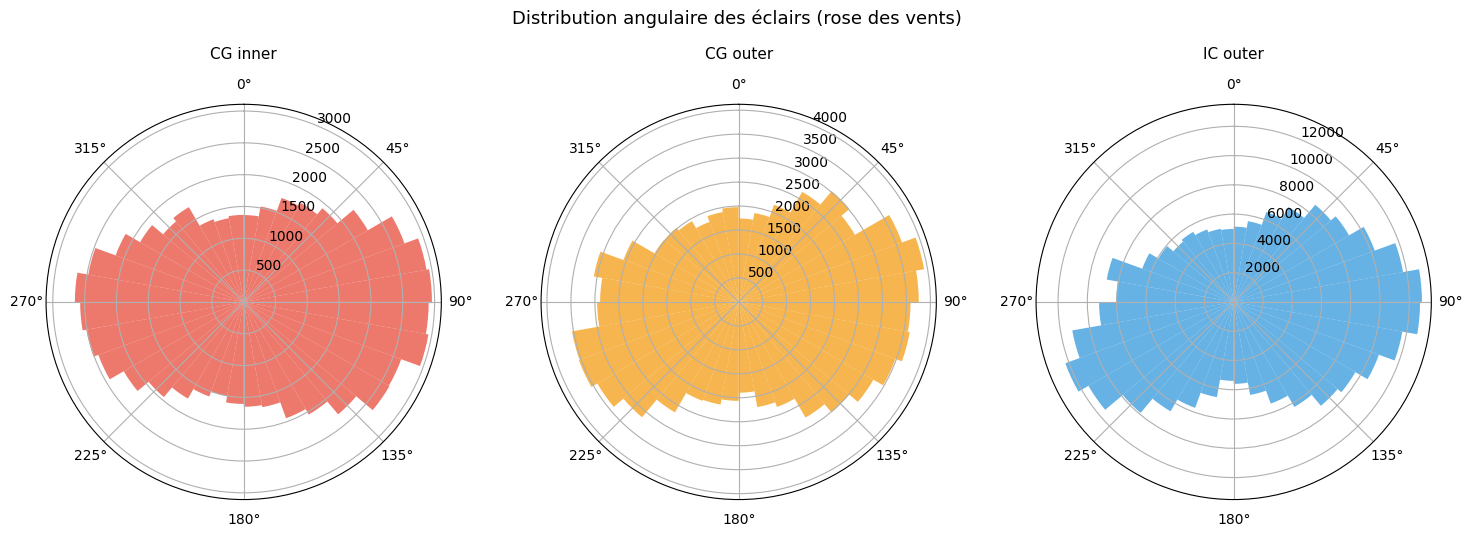

In [33]:
# Chunk 26
fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw=dict(projection='polar'))
configs = [
    ("CG inner", (df_raw["type"] == "CG") & (df_raw["zone"] == "inner"), "#e74c3c"),
    ("CG outer", (df_raw["type"] == "CG") & (df_raw["zone"] == "outer"), "#f39c12"),
    ("IC outer", (df_raw["type"] == "IC") & (df_raw["zone"] == "outer"), "#3498db"),
]
for ax, (label, mask, color) in zip(axes, configs):
    az_rad = np.radians(df_raw.loc[mask, "azimuth"].dropna())
    ax.hist(az_rad, bins=36, color=color, alpha=0.75)
    ax.set_title(label, pad=14, fontsize=11)
    ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
plt.suptitle("Distribution angulaire des éclairs (rose des vents)", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

Corrélation dispersion angulaire ↔ durée alerte : 0.448
count    2384.0
mean       37.7
std        32.2
min        -0.0
25%        11.2
50%        29.0
75%        58.1
max       184.9
Name: az_circ_std_alert, dtype: float64


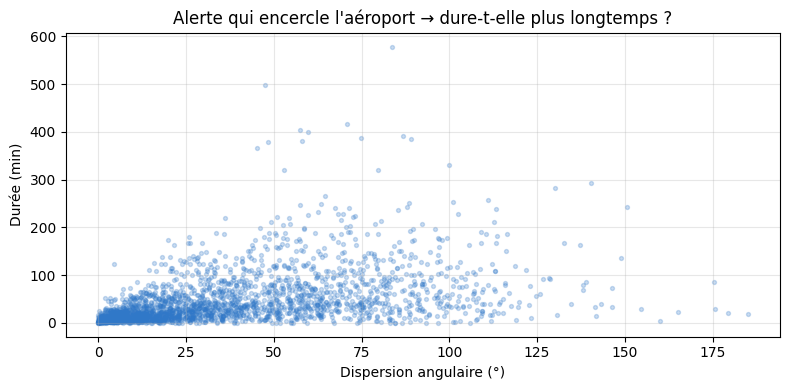

In [34]:
# Chunk 27
def circular_std(azimuths_deg):
    if len(azimuths_deg) < 2:
        return np.nan
    rad = np.radians(azimuths_deg)
    R = np.sqrt(np.mean(np.cos(rad))**2 + np.mean(np.sin(rad))**2)
    return np.degrees(np.sqrt(-2 * np.log(np.clip(R, 1e-10, 1))))

az_disp = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .groupby(["airport","airport_alert_id"])["azimuth"]
    .apply(circular_std).reset_index(name="az_circ_std_alert")
    .merge(df_alerts[["airport","airport_alert_id","duration"]], on=["airport","airport_alert_id"], how="left")
)
corr_disp = az_disp["az_circ_std_alert"].corr(az_disp["duration"])
print(f"Corrélation dispersion angulaire ↔ durée alerte : {corr_disp:.3f}")
print(az_disp["az_circ_std_alert"].describe().round(1))

plt.figure(figsize=(8, 4))
plt.scatter(az_disp["az_circ_std_alert"], az_disp["duration"], alpha=0.25, s=8, color="#3078c8")
plt.xlabel("Dispersion angulaire (°)"); plt.ylabel("Durée (min)")
plt.title("Alerte qui encercle l'aéroport → dure-t-elle plus longtemps ?")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

Corrélation déplacement angulaire ↔ durée : 0.234
count    1631.0
mean       49.8
std        47.3
min         0.0
25%        13.4
50%        32.7
75%        74.3
max       179.7
Name: az_shift_deg, dtype: float64


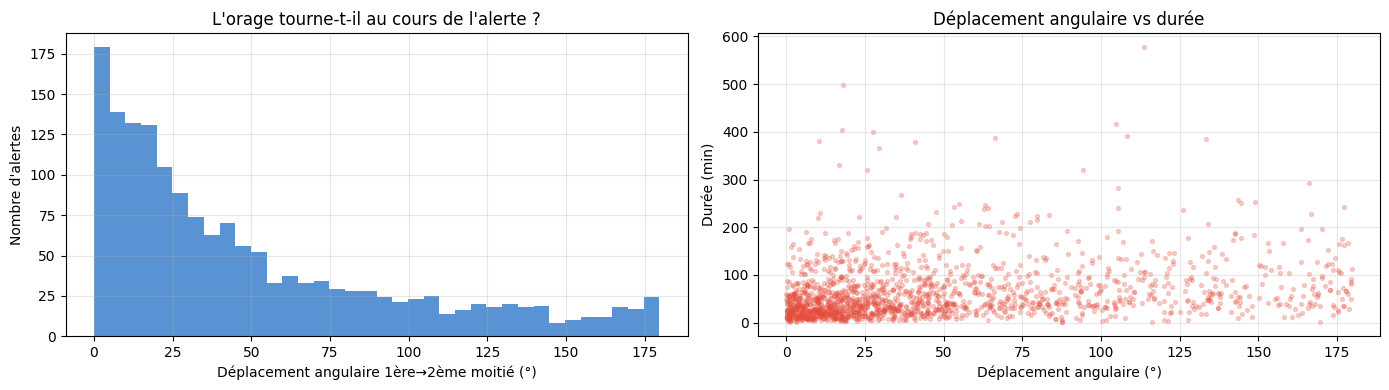

In [35]:
# Chunk 28
def mean_circular_angle(azimuths_deg):
    rad = np.radians(azimuths_deg)
    return np.degrees(np.arctan2(np.mean(np.sin(rad)), np.mean(np.cos(rad)))) % 360

def angular_diff(a1, a2):
    return abs((a2 - a1 + 180) % 360 - 180)

cg_inner_raw = df_raw[
    (df_raw["type"] == "CG") & (df_raw["zone"] == "inner") & (df_raw["airport_alert_id"].notna())
].copy()

def directional_shift(group):
    group = group.sort_values("date"); n = len(group)
    if n < 4: return np.nan
    mid = n // 2
    return angular_diff(mean_circular_angle(group.iloc[:mid]["azimuth"].values),
                        mean_circular_angle(group.iloc[mid:]["azimuth"].values))

shift = (
    cg_inner_raw.groupby(["airport","airport_alert_id"])
    .apply(directional_shift, include_groups=False)
    .reset_index(name="az_shift_deg")
    .merge(df_alerts[["airport","airport_alert_id","duration"]], on=["airport","airport_alert_id"], how="left")
)
corr_shift = shift["az_shift_deg"].corr(shift["duration"])
print(f"Corrélation déplacement angulaire ↔ durée : {corr_shift:.3f}")
print(shift["az_shift_deg"].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(shift["az_shift_deg"].dropna(), bins=36, alpha=0.8, color="#3078c8")
axes[0].set_xlabel("Déplacement angulaire 1ère→2ème moitié (°)"); axes[0].set_ylabel("Nombre d'alertes")
axes[0].set_title("L'orage tourne-t-il au cours de l'alerte ?"); axes[0].grid(alpha=0.3)
axes[1].scatter(shift["az_shift_deg"], shift["duration"], alpha=0.25, s=8, color="#e74c3c")
axes[1].set_xlabel("Déplacement angulaire (°)"); axes[1].set_ylabel("Durée (min)")
axes[1].set_title("Déplacement angulaire vs durée"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [36]:
# Chunk 29
merged = (
    az_disp.dropna()
    .merge(
        df_raw[df_raw["airport_alert_id"].notna()]
        .groupby(["airport","airport_alert_id"])["dist"]
        .min().reset_index(name="min_dist"),
        on=["airport","airport_alert_id"], how="left"
    )
    .dropna(subset=["min_dist","az_circ_std_alert","duration"])
)
med = merged["duration"].median()
merged["y"] = (merged["duration"] > med).astype(int)
sc = StandardScaler()
X1 = sc.fit_transform(merged[["min_dist"]])
X2 = sc.fit_transform(merged[["min_dist","az_circ_std_alert"]])
auc1 = roc_auc_score(merged["y"], LogisticRegression().fit(X1, merged["y"]).predict_proba(X1)[:, 1])
auc2 = roc_auc_score(merged["y"], LogisticRegression().fit(X2, merged["y"]).predict_proba(X2)[:, 1])
print(f"AUC dist_min seul                : {auc1:.4f}")
print(f"AUC dist_min + az_circ_std_alert : {auc2:.4f}")
print(f"Gain                             : {auc2 - auc1:+.4f}")

AUC dist_min seul                : 0.7996
AUC dist_min + az_circ_std_alert : 0.8253
Gain                             : +0.0257


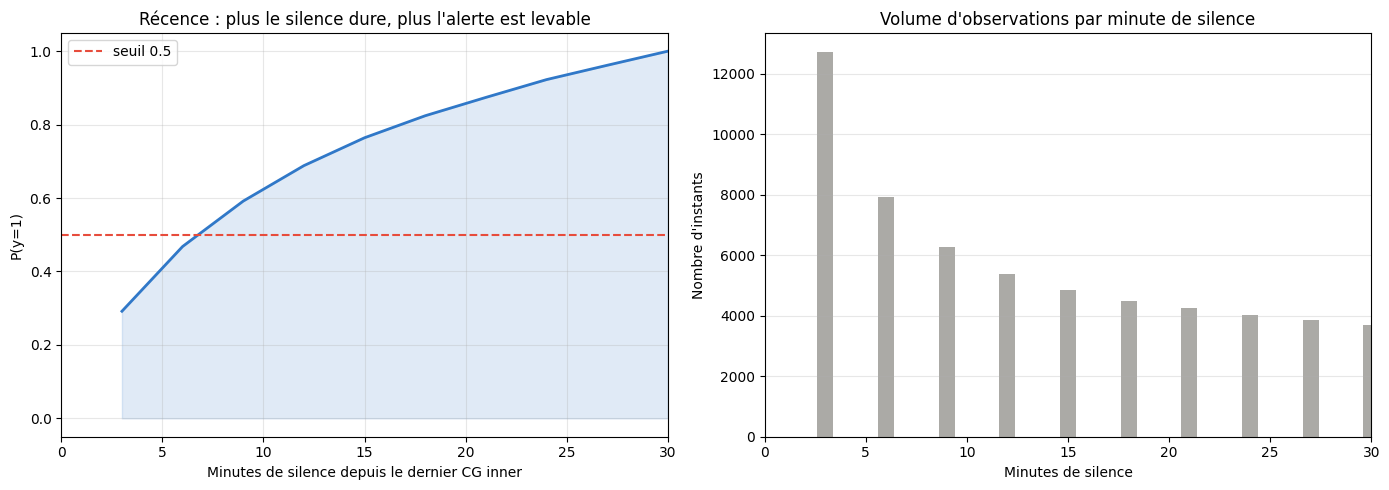

In [38]:
# Chunk 30
curve = (
    df_silence.groupby("min_since_cg")["y"]
    .agg(["mean","count"]).reset_index()
    .rename(columns={"mean":"p_y1","count":"n"})
)
curve = curve[curve["n"] >= 50]

for t in [1, 5, 10, 20]:
    row = curve[curve["min_since_cg"] == t]
    if len(row):
        print(f"P(y=1) à {t:2d} min  : {row['p_y1'].values[0]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(curve["min_since_cg"], curve["p_y1"], color="#3078c8", linewidth=2)
axes[0].axhline(0.5, color="#e74c3c", linestyle="--", label="seuil 0.5")
axes[0].fill_between(curve["min_since_cg"], curve["p_y1"], alpha=0.15, color="#3078c8")
axes[0].set_xlabel("Minutes de silence depuis le dernier CG inner")
axes[0].set_ylabel("P(y=1)"); axes[0].set_title("Récence : plus le silence dure, plus l'alerte est levable")
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_xlim(0, 30)
axes[1].bar(curve["min_since_cg"], curve["n"], color="#888780", alpha=0.7)
axes[1].set_xlabel("Minutes de silence"); axes[1].set_ylabel("Nombre d'instants")
axes[1].set_title("Volume d'observations par minute de silence")
axes[1].grid(alpha=0.3, axis="y"); axes[1].set_xlim(0, 30)
plt.tight_layout(); plt.show()

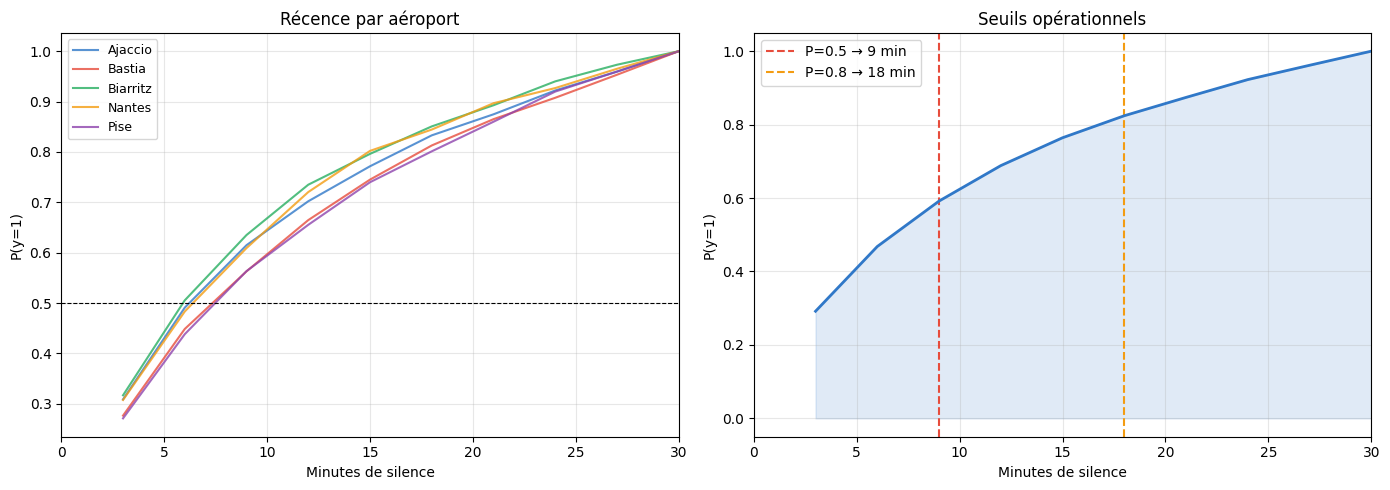

In [39]:
# Chunk 31
colors = {"Ajaccio":"#3078c8","Bastia":"#e74c3c","Biarritz":"#27ae60","Nantes":"#f39c12","Pise":"#8e44ad"}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for airport, g in df_silence.groupby("airport"):
    c = (g.assign(min_since_cg=g["minutes_since_reference_cg"].round(0).astype(int))
         .groupby("min_since_cg")["y"].agg(["mean","count"]).reset_index())
    c = c[c["count"] >= 20]
    axes[0].plot(c["min_since_cg"], c["mean"], label=airport, color=colors[airport], linewidth=1.5, alpha=0.8)
axes[0].axhline(0.5, color="black", linestyle="--", linewidth=0.8)
axes[0].set_xlim(0, 30); axes[0].set_xlabel("Minutes de silence")
axes[0].set_ylabel("P(y=1)"); axes[0].set_title("Récence par aéroport")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

for seuil, color, label in [(0.5,"#e74c3c","P=0.5"),(0.8,"#f39c12","P=0.8")]:
    above = curve[curve["p_y1"] >= seuil]
    if len(above) > 0:
        t_cross = above["min_since_cg"].iloc[0]
        axes[1].axvline(t_cross, color=color, linestyle="--", label=f"{label} → {t_cross} min")
axes[1].plot(curve["min_since_cg"], curve["p_y1"], color="#3078c8", linewidth=2)
axes[1].fill_between(curve["min_since_cg"], curve["p_y1"], alpha=0.15, color="#3078c8")
axes[1].set_xlim(0, 30); axes[1].set_xlabel("Minutes de silence")
axes[1].set_ylabel("P(y=1)"); axes[1].set_title("Seuils opérationnels")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [40]:
# Chunk 32
CLOSE_KM = 3.0
df_silence["had_close_cg"] = df_silence["dist_min"] < CLOSE_KM
print("Répartition alertes avec/sans CG < 3km :")
print(df_silence.groupby("had_close_cg")["alert_group"].nunique())
print(f"\nSoit {100*df_silence['had_close_cg'].mean():.1f}% des instants avec au moins un CG < {CLOSE_KM}km")

Répartition alertes avec/sans CG < 3km :
had_close_cg
False    3510
True      752
Name: alert_group, dtype: int64

Soit 22.9% des instants avec au moins un CG < 3.0km


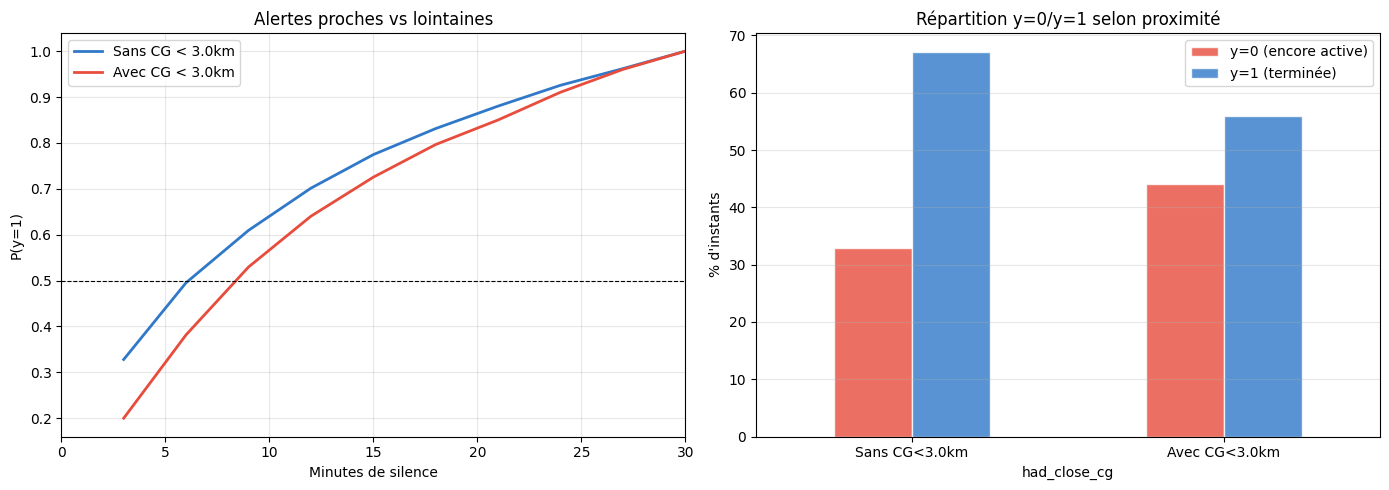

In [41]:
# Chunk 33
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for had_close, label, color in [
    (False, f"Sans CG < {CLOSE_KM}km", "#3078c8"),
    (True,  f"Avec CG < {CLOSE_KM}km", "#e74c3c"),
]:
    sub = df_silence[df_silence["had_close_cg"] == had_close]
    c = (sub.groupby("min_since_cg")["y"].agg(["mean","count"]).reset_index()
         .rename(columns={"mean":"p_y1","count":"n"}))
    c = c[c["n"] >= 30]
    axes[0].plot(c["min_since_cg"], c["p_y1"], label=label, color=color, linewidth=2)
axes[0].axhline(0.5, color="black", linestyle="--", linewidth=0.8)
axes[0].set_xlim(0, 30); axes[0].set_xlabel("Minutes de silence")
axes[0].set_ylabel("P(y=1)"); axes[0].set_title("Alertes proches vs lointaines")
axes[0].legend(); axes[0].grid(alpha=0.3)

counts = df_silence.groupby(["had_close_cg","y"]).size().unstack(fill_value=0)
(counts.div(counts.sum(axis=1), axis=0)*100).plot(
    kind="bar", ax=axes[1], color=["#e74c3c","#3078c8"], alpha=0.8, edgecolor="white")
axes[1].set_xticklabels([f"Sans CG<{CLOSE_KM}km", f"Avec CG<{CLOSE_KM}km"], rotation=0)
axes[1].set_ylabel("% d'instants"); axes[1].set_title("Répartition y=0/y=1 selon proximité")
axes[1].legend(["y=0 (encore active)","y=1 (terminée)"]); axes[1].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

In [42]:
# Chunk 34
print("=== Seuils opérationnels selon la dangerosité ===\n")
for had_close, label in [(False, f"Sans CG < {CLOSE_KM}km"), (True, f"Avec CG < {CLOSE_KM}km")]:
    sub = df_silence[df_silence["had_close_cg"] == had_close]
    c = (sub.groupby("min_since_cg")["y"].agg(["mean","count"]).reset_index()
         .rename(columns={"mean":"p_y1","count":"n"}))
    c = c[c["n"] >= 30]
    for seuil in [0.5, 0.8]:
        above = c[c["p_y1"] >= seuil]
        if len(above) > 0:
            print(f"{label} — P(y=1) > {seuil} atteint à : {above['min_since_cg'].iloc[0]} min")
        else:
            print(f"{label} — P(y=1) > {seuil} : jamais atteint sur 30 min")
    print()

=== Seuils opérationnels selon la dangerosité ===

Sans CG < 3.0km — P(y=1) > 0.5 atteint à : 9 min
Sans CG < 3.0km — P(y=1) > 0.8 atteint à : 18 min

Avec CG < 3.0km — P(y=1) > 0.5 atteint à : 9 min
Avec CG < 3.0km — P(y=1) > 0.8 atteint à : 21 min



In [43]:
# Chunk 35
lre_per_alert = (
    df_raw[df_raw["airport_alert_id"].notna()]
    .assign(is_lre=lambda x: x["dist"] < LRE_DIST)
    .groupby(["airport","airport_alert_id"])["is_lre"]
    .agg(["sum","max"]).reset_index()
    .rename(columns={"sum":"n_lre","max":"has_lre"})
)
print("=== Distribution du nombre de LRE par alerte ===\n")
print(lre_per_alert["n_lre"].describe().round(2))
print(f"\nAlertes sans LRE       : {(lre_per_alert['n_lre']==0).sum()}")
print(f"Alertes avec 1 LRE     : {(lre_per_alert['n_lre']==1).sum()}")
print(f"Alertes avec 2-5 LRE   : {((lre_per_alert['n_lre']>=2)&(lre_per_alert['n_lre']<=5)).sum()}")
print(f"Alertes avec > 5 LRE   : {(lre_per_alert['n_lre']>5).sum()}")
print(f"\nTotal alertes avec LRE : {lre_per_alert['has_lre'].sum()} ({100*lre_per_alert['has_lre'].mean():.1f}%)")

=== Distribution du nombre de LRE par alerte ===

count    3708.00
mean        0.44
std         2.23
min         0.00
25%         0.00
50%         0.00
75%         0.00
max        64.00
Name: n_lre, dtype: float64

Alertes sans LRE       : 3230
Alertes avec 1 LRE     : 246
Alertes avec 2-5 LRE   : 154
Alertes avec > 5 LRE   : 78

Total alertes avec LRE : 478 (12.9%)


In [44]:
# Chunk 36
SILENCE_THRESHOLD_MIN = 5
rebonds = []
for (airport, alert_id), group in df_raw[df_raw["airport_alert_id"].notna()].groupby(["airport","airport_alert_id"]):
    group = group.sort_values("date").reset_index(drop=True)
    lre_in_alert = group[group["dist"] < LRE_DIST]
    if len(lre_in_alert) == 0:
        continue
    for _, lre_row in lre_in_alert.iterrows():
        t_lre = lre_row["date"]
        events_before = group[(group["date"] > t_lre - pd.Timedelta(minutes=SILENCE_THRESHOLD_MIN)) & (group["date"] < t_lre)]
        if len(events_before) == 0:
            rebonds.append({"airport":airport,"airport_alert_id":alert_id,"lre_date":t_lre,
                            "lre_dist":lre_row["dist"],"lre_type":lre_row["type"]})

rebonds_df = pd.DataFrame(rebonds)
print(f"=== LRE apparus après {SILENCE_THRESHOLD_MIN} min de silence ===\n")
print(f"Nombre de rebonds détectés : {len(rebonds_df)}")
if len(rebonds_df) > 0:
    print(f"Alertes concernées         : {rebonds_df['airport_alert_id'].nunique()}")
    print("\nPar aéroport :")
    print(rebonds_df.groupby("airport").size().to_string())
    print("\nType des LRE rebonds :")
    print(rebonds_df["lre_type"].value_counts().to_string())

=== LRE apparus après 5 min de silence ===

Nombre de rebonds détectés : 146
Alertes concernées         : 125

Par aéroport :
airport
Ajaccio     32
Bastia      29
Biarritz    23
Nantes      14
Pise        48

Type des LRE rebonds :
lre_type
CG    146


In [45]:
# Chunk 37
print("=== Rebonds LRE selon le seuil de silence ===\n")
print(f"{'Silence min':>12} | {'Nb rebonds':>10} | {'Alertes':>8} | {'% alertes LRE':>14}")
print("-" * 50)
for seuil in [1, 2, 3, 5, 7, 10, 15, 20]:
    n_rebonds = 0
    alertes_rebond = set()
    for (airport, alert_id), group in df_raw[df_raw["airport_alert_id"].notna()].groupby(["airport","airport_alert_id"]):
        group = group.sort_values("date").reset_index(drop=True)
        lre_in_alert = group[group["dist"] < LRE_DIST]
        if len(lre_in_alert) == 0:
            continue
        for _, lre_row in lre_in_alert.iterrows():
            t_lre = lre_row["date"]
            if len(group[(group["date"] > t_lre - pd.Timedelta(minutes=seuil)) & (group["date"] < t_lre)]) == 0:
                n_rebonds += 1; alertes_rebond.add(alert_id)
    n_lre_base = lre_per_alert["has_lre"].sum()
    pct = 100 * len(alertes_rebond) / n_lre_base if n_lre_base > 0 else 0
    print(f"{seuil:>12} | {n_rebonds:>10} | {len(alertes_rebond):>8} | {pct:>13.1f}%")

=== Rebonds LRE selon le seuil de silence ===

 Silence min | Nb rebonds |  Alertes |  % alertes LRE
--------------------------------------------------
           1 |        553 |      300 |          62.8%
           2 |        329 |      235 |          49.2%
           3 |        228 |      180 |          37.7%
           5 |        146 |      125 |          26.2%
           7 |        123 |      111 |          23.2%
          10 |         95 |       88 |          18.4%
          15 |         73 |       71 |          14.9%
          20 |         59 |       58 |          12.1%


P(y=1) selon présence de LRE :
          mean  count
has_lre              
False    0.702  46027
True     0.418  11434


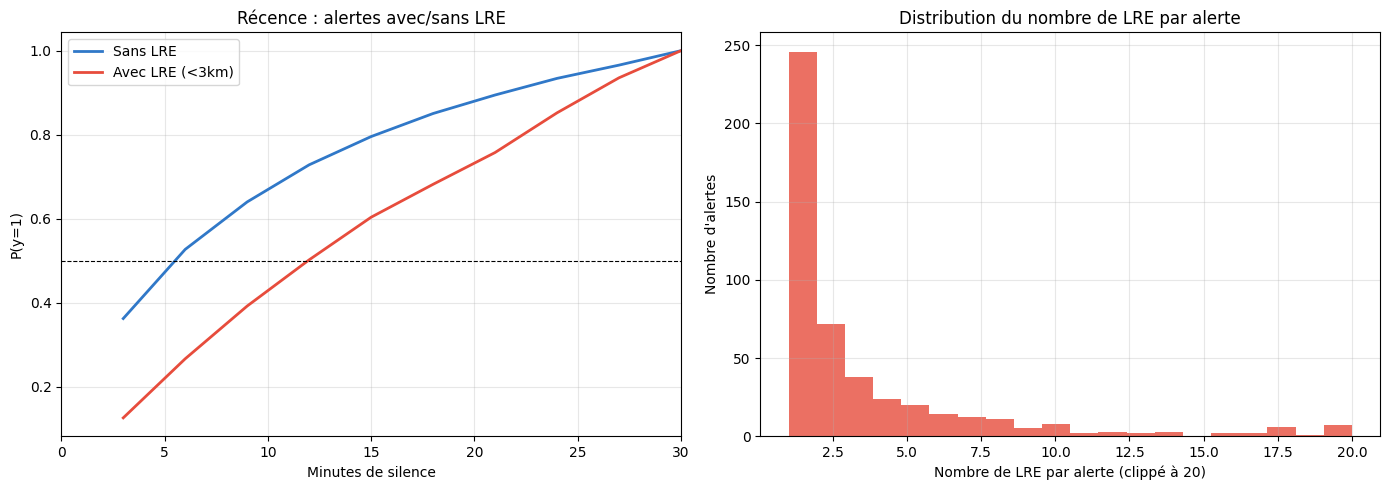

In [48]:
# Chunk 38
df_silence["airport_alert_id"] = df_silence["airport_alert_id"].astype(str)
lre_per_alert["airport_alert_id"] = lre_per_alert["airport_alert_id"].astype(str)

df_silence = df_silence.merge(
    lre_per_alert[["airport","airport_alert_id","n_lre","has_lre"]],
    on=["airport","airport_alert_id"], how="left"
)
df_silence["has_lre"] = df_silence["has_lre"].fillna(False)

print("P(y=1) selon présence de LRE :")
print(df_silence.groupby("has_lre")["y"].agg(["mean","count"]).round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for has_lre, label, color in [(False,"Sans LRE","#3078c8"),(True,"Avec LRE (<3km)","#e74c3c")]:
    sub = df_silence[df_silence["has_lre"] == has_lre]
    c = (sub.groupby("min_since_cg")["y"].agg(["mean","count"]).reset_index()
         .rename(columns={"mean":"p_y1","count":"n"}))
    c = c[c["n"] >= 30]
    axes[0].plot(c["min_since_cg"], c["p_y1"], label=label, color=color, linewidth=2)
axes[0].axhline(0.5, color="black", linestyle="--", linewidth=0.8)
axes[0].set_xlim(0, 30); axes[0].set_xlabel("Minutes de silence")
axes[0].set_ylabel("P(y=1)"); axes[0].set_title("Récence : alertes avec/sans LRE")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(lre_per_alert[lre_per_alert["n_lre"] > 0]["n_lre"].clip(upper=20),
             bins=20, color="#e74c3c", alpha=0.8)
axes[1].set_xlabel("Nombre de LRE par alerte (clippé à 20)"); axes[1].set_ylabel("Nombre d'alertes")
axes[1].set_title("Distribution du nombre de LRE par alerte"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [49]:
# Chunk 39
timing_rows = []
for (airport, alert_id), group in df_raw[df_raw["airport_alert_id"].notna()].groupby(["airport","airport_alert_id"]):
    group = group.sort_values("date").reset_index(drop=True)
    lre = group[group["dist"] < LRE_DIST]
    if len(lre) == 0:
        continue
    t_debut = group["date"].iloc[0]; t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds() / 60.0
    if duree == 0:
        continue
    t_premier_lre = lre["date"].iloc[0]; t_dernier_lre = lre["date"].iloc[-1]
    timing_rows.append({
        "airport":airport, "airport_alert_id":alert_id, "duree_alerte_min":duree, "n_lre":len(lre),
        "pos_premier_lre":   (t_premier_lre - t_debut).total_seconds()/60.0/duree,
        "pos_dernier_lre":   (t_dernier_lre - t_debut).total_seconds()/60.0/duree,
        "delai_premier_lre_min":       (t_premier_lre - t_debut).total_seconds()/60.0,
        "temps_apres_dernier_lre_min": (t_fin - t_dernier_lre).total_seconds()/60.0,
    })
timing_df = pd.DataFrame(timing_rows)
print(f"Alertes avec LRE analysées : {len(timing_df)}")

Alertes avec LRE analysées : 457


In [50]:
# Chunk 40
print("=== Position relative du premier LRE (0=début, 1=fin) ===\n")
print(timing_df["pos_premier_lre"].describe().round(3))
print("\n=== Délai avant le premier LRE (minutes) ===\n")
print(timing_df["delai_premier_lre_min"].describe().round(2))
print("\n=== Temps restant après le DERNIER LRE ===\n")
print(timing_df["temps_apres_dernier_lre_min"].describe().round(2))

timing_df["phase_premier_lre"] = pd.cut(timing_df["pos_premier_lre"],
    bins=[0,0.33,0.66,1.0], labels=["début (0-33%)","milieu (33-66%)","fin (66-100%)"], include_lowest=True)
print("\n=== Dans quelle phase survient le premier LRE ? ===\n")
for phase, n in timing_df["phase_premier_lre"].value_counts().sort_index().items():
    print(f"  {phase} : {n} alertes ({100*n/len(timing_df):.1f}%)")

=== Position relative du premier LRE (0=début, 1=fin) ===

count    457.000
mean       0.436
std        0.285
min        0.000
25%        0.213
50%        0.395
75%        0.645
max        1.000
Name: pos_premier_lre, dtype: float64

=== Délai avant le premier LRE (minutes) ===

count    457.00
mean      40.63
std       35.91
min        0.00
25%       15.02
50%       32.07
75%       55.17
max      278.02
Name: delai_premier_lre_min, dtype: float64

=== Temps restant après le DERNIER LRE ===

count    457.00
mean      43.29
std       44.15
min        0.00
25%       13.70
50%       30.25
75%       60.03
max      265.47
Name: temps_apres_dernier_lre_min, dtype: float64

=== Dans quelle phase survient le premier LRE ? ===

  début (0-33%) : 181 alertes (39.6%)
  milieu (33-66%) : 170 alertes (37.2%)
  fin (66-100%) : 106 alertes (23.2%)


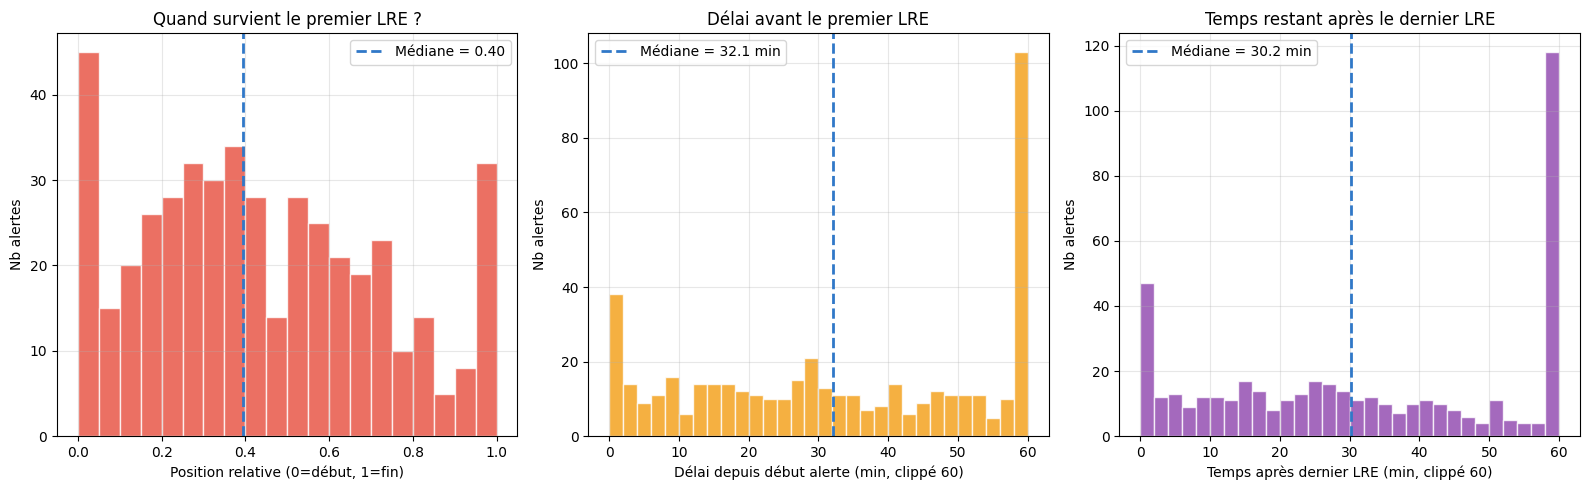

In [51]:
# Chunk 41
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].hist(timing_df["pos_premier_lre"], bins=20, color="#e74c3c", alpha=0.8, edgecolor="white")
axes[0].axvline(timing_df["pos_premier_lre"].median(), color="#3078c8", linestyle="--", linewidth=2,
                label=f"Médiane = {timing_df['pos_premier_lre'].median():.2f}")
axes[0].set_xlabel("Position relative (0=début, 1=fin)"); axes[0].set_ylabel("Nb alertes")
axes[0].set_title("Quand survient le premier LRE ?"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(timing_df["delai_premier_lre_min"].clip(upper=60), bins=30, color="#f39c12", alpha=0.8, edgecolor="white")
axes[1].axvline(timing_df["delai_premier_lre_min"].median(), color="#3078c8", linestyle="--", linewidth=2,
                label=f"Médiane = {timing_df['delai_premier_lre_min'].median():.1f} min")
axes[1].set_xlabel("Délai depuis début alerte (min, clippé 60)"); axes[1].set_ylabel("Nb alertes")
axes[1].set_title("Délai avant le premier LRE"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].hist(timing_df["temps_apres_dernier_lre_min"].clip(upper=60), bins=30, color="#8e44ad", alpha=0.8, edgecolor="white")
axes[2].axvline(timing_df["temps_apres_dernier_lre_min"].median(), color="#3078c8", linestyle="--", linewidth=2,
                label=f"Médiane = {timing_df['temps_apres_dernier_lre_min'].median():.1f} min")
axes[2].set_xlabel("Temps après dernier LRE (min, clippé 60)"); axes[2].set_ylabel("Nb alertes")
axes[2].set_title("Temps restant après le dernier LRE"); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [52]:
# Chunk 42
rows = []
for (airport, alert_id), group in df_raw[df_raw["airport_alert_id"].notna()].groupby(["airport","airport_alert_id"]):
    group = group.sort_values("date").reset_index(drop=True)
    lre = group[group["dist"] < LRE_DIST].reset_index(drop=True)
    if len(lre) == 0: continue
    t_debut = group["date"].iloc[0]; t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds()/60.0
    if duree == 0: continue
    for i, lre_row in lre.iterrows():
        t_lre = lre_row["date"]
        pos = (t_lre - t_debut).total_seconds()/60.0/duree
        gap_since_prev = (t_lre - lre.iloc[i-1]["date"]).total_seconds()/60.0 if i > 0 else np.nan
        rows.append({"airport":airport,"alert_id":alert_id,"pos_relative":round(pos,3),
                     "in_second_half":pos>=0.5,"has_previous_lre":i>0,
                     "gap_since_prev_lre_min":gap_since_prev,"lre_type":lre_row["type"],"lre_dist":lre_row["dist"]})
lre_df = pd.DataFrame(rows)
print(f"Total LRE analysés : {len(lre_df)}")
print(f"LRE en 2ème moitié : {lre_df['in_second_half'].sum()} ({100*lre_df['in_second_half'].mean():.1f}%)")

Total LRE analysés : 1617
LRE en 2ème moitié : 759 (46.9%)


In [53]:
# Chunk 42
rows = []
for (airport, alert_id), group in df_raw[df_raw["airport_alert_id"].notna()].groupby(["airport","airport_alert_id"]):
    group = group.sort_values("date").reset_index(drop=True)
    lre = group[group["dist"] < LRE_DIST].reset_index(drop=True)
    if len(lre) == 0: continue
    t_debut = group["date"].iloc[0]; t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds()/60.0
    if duree == 0: continue
    for i, lre_row in lre.iterrows():
        t_lre = lre_row["date"]
        pos = (t_lre - t_debut).total_seconds()/60.0/duree
        gap_since_prev = (t_lre - lre.iloc[i-1]["date"]).total_seconds()/60.0 if i > 0 else np.nan
        rows.append({"airport":airport,"alert_id":alert_id,"pos_relative":round(pos,3),
                     "in_second_half":pos>=0.5,"has_previous_lre":i>0,
                     "gap_since_prev_lre_min":gap_since_prev,"lre_type":lre_row["type"],"lre_dist":lre_row["dist"]})
lre_df = pd.DataFrame(rows)
print(f"Total LRE analysés : {len(lre_df)}")
print(f"LRE en 2ème moitié : {lre_df['in_second_half'].sum()} ({100*lre_df['in_second_half'].mean():.1f}%)")

Total LRE analysés : 1617
LRE en 2ème moitié : 759 (46.9%)


In [55]:
# Chunk 43
lre_2nd = lre_df[lre_df["in_second_half"]].copy()
print(f"Total LRE en 2ème moitié : {len(lre_2nd)}")
print(f"Précédés d'un LRE : {lre_2nd['has_previous_lre'].sum()} ({100*lre_2nd['has_previous_lre'].mean():.1f}%)")
print(f"Rebonds purs       : {(~lre_2nd['has_previous_lre']).sum()} ({100*(~lre_2nd['has_previous_lre']).mean():.1f}%)")
gaps = lre_2nd[lre_2nd["has_previous_lre"]]["gap_since_prev_lre_min"]
print(f"\n< 5 min  : {(gaps<5).sum()} ({100*(gaps<5).mean():.1f}%)")
print(f"5-15 min : {((gaps>=5)&(gaps<15)).sum()} ({100*((gaps>=5)&(gaps<15)).mean():.1f}%)")
print(f"> 30 min : {(gaps>=30).sum()} ({100*(gaps>=30).mean():.1f}%)")

Total LRE en 2ème moitié : 759
Précédés d'un LRE : 574 (75.6%)
Rebonds purs       : 185 (24.4%)

< 5 min  : 379 (66.0%)
5-15 min : 106 (18.5%)
> 30 min : 43 (7.5%)


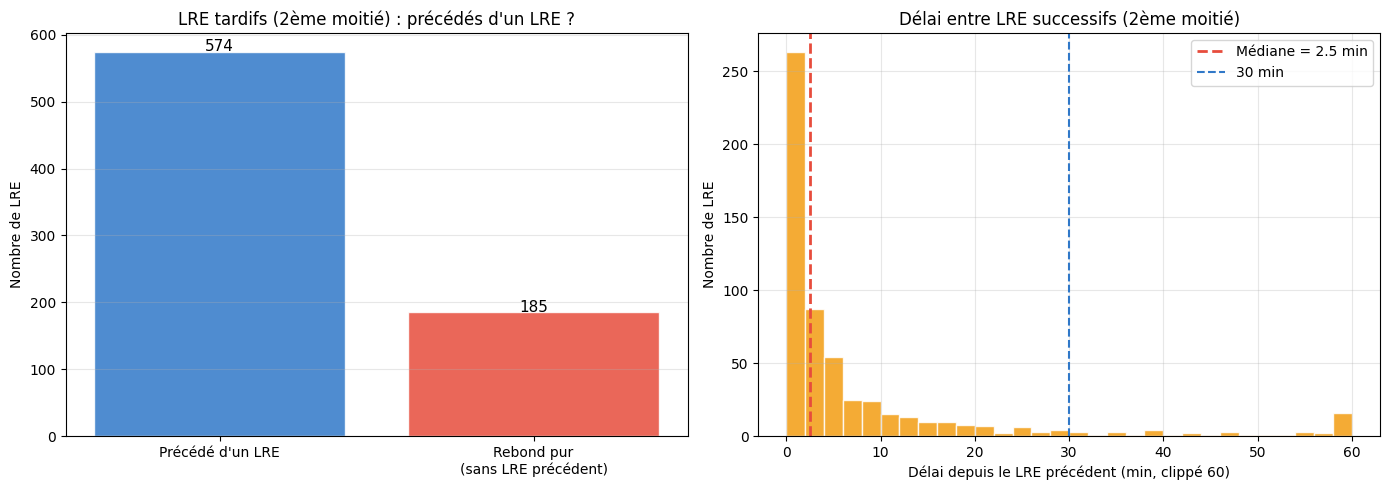

In [56]:
# Chunk 44
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ["Précédé d'un LRE", "Rebond pur\n(sans LRE précédent)"]
vals = [lre_2nd["has_previous_lre"].sum(), (~lre_2nd["has_previous_lre"]).sum()]
axes[0].bar(labels, vals, color=["#3078c8","#e74c3c"], alpha=0.85, edgecolor="white")
for i, v in enumerate(vals):
    axes[0].text(i, v + 1, str(v), ha="center", fontsize=11, fontweight="500")
axes[0].set_title("LRE tardifs (2ème moitié) : précédés d'un LRE ?")
axes[0].set_ylabel("Nombre de LRE"); axes[0].grid(alpha=0.3, axis="y")

gaps_plot = lre_2nd[lre_2nd["has_previous_lre"]]["gap_since_prev_lre_min"].clip(upper=60)
axes[1].hist(gaps_plot, bins=30, color="#f39c12", alpha=0.85, edgecolor="white")
axes[1].axvline(gaps_plot.median(), color="#e74c3c", linestyle="--", linewidth=2,
                label=f"Médiane = {gaps_plot.median():.1f} min")
axes[1].axvline(30, color="#3078c8", linestyle="--", linewidth=1.5, label="30 min")
axes[1].set_xlabel("Délai depuis le LRE précédent (min, clippé 60)"); axes[1].set_ylabel("Nombre de LRE")
axes[1].set_title("Délai entre LRE successifs (2ème moitié)"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [57]:
# Chunk 45
rebond_pur_alerts = set()
for (airport, alert_id), group in df_raw[df_raw["airport_alert_id"].notna()].groupby(["airport","airport_alert_id"]):
    group = group.sort_values("date").reset_index(drop=True)
    lre = group[group["dist"] < LRE_DIST].reset_index(drop=True)
    if len(lre) == 0: continue
    t_debut = group["date"].iloc[0]; t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds()/60.0
    if duree == 0: continue
    for i, lre_row in lre.iterrows():
        t_lre = lre_row["date"]
        pos = (t_lre - t_debut).total_seconds()/60.0/duree
        if pos >= 0.5 and i == 0:
            rebond_pur_alerts.add((airport, alert_id)); break

print(f"Alertes avec rebond pur : {len(rebond_pur_alerts)}")

Alertes avec rebond pur : 185


In [58]:
# Chunk 46
alert_stats = []
for (airport, alert_id), group in df_raw[df_raw["airport_alert_id"].notna()].groupby(["airport","airport_alert_id"]):
    group = group.sort_values("date").reset_index(drop=True)
    cg_inner = group[(group["type"] == "CG") & (group["zone"] == "inner")]
    lre = group[group["dist"] < LRE_DIST]
    t_debut = group["date"].iloc[0]; t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds()/60.0
    cat = "rebond pur" if (airport,alert_id) in rebond_pur_alerts else ("LRE normal" if len(lre)>0 else "sans LRE")
    alert_stats.append({"airport":airport,"alert_id":alert_id,"categorie":cat,"duree_min":duree,
                         "n_cg_inner":len(cg_inner),"n_lre":len(lre),"dist_min":group["dist"].min(),
                         "mois":group["date"].iloc[0].month,"heure":group["date"].iloc[0].hour})
stats_df = pd.DataFrame(alert_stats)

print("=== Profil des alertes selon catégorie ===\n")
print(stats_df.groupby("categorie")[["duree_min","n_cg_inner","dist_min"]].agg(["mean","median"]).round(2).to_string())

=== Profil des alertes selon catégorie ===

           duree_min        n_cg_inner        dist_min       
                mean median       mean median     mean median
categorie                                                    
LRE normal    105.64  85.35     134.73   53.0     1.58   1.46
rebond pur     86.22  76.70      63.22   34.0     1.69   1.65
sans LRE       19.76   5.46       7.26    2.0    12.32  12.70


In [59]:
# Chunk 47
gap_rows = []
for (airport, alert_id), group in df_raw[df_raw["airport_alert_id"].notna()].groupby(["airport","airport_alert_id"]):
    if (airport, alert_id) not in rebond_pur_alerts: continue
    group = group.sort_values("date").reset_index(drop=True)
    lre = group[group["dist"] < LRE_DIST].reset_index(drop=True)
    t_debut = group["date"].iloc[0]; t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds()/60.0
    if duree == 0: continue
    for i, lre_row in lre.iterrows():
        t_lre = lre_row["date"]
        pos = (t_lre - t_debut).total_seconds()/60.0/duree
        if pos >= 0.5 and i == 0:
            before_all = group[group["date"] < t_lre]
            if len(before_all) == 0: break
            gap_min = (t_lre - before_all["date"].iloc[-1]).total_seconds()/60.0
            cg_ib = group[(group["date"] < t_lre)&(group["type"]=="CG")&(group["zone"]=="inner")]
            gap_cg = (t_lre - cg_ib["date"].iloc[-1]).total_seconds()/60.0 if len(cg_ib)>0 else np.nan
            gap_rows.append({"airport":airport,"alert_id":alert_id,"duree_alerte_min":duree,"t_lre":t_lre,
                              "gap_depuis_dernier_eclair_min":gap_min,"gap_depuis_dernier_cg_inner_min":gap_cg,
                              "lre_dist":lre_row["dist"]}); break

gap_df = pd.DataFrame(gap_rows)
print("=== Gap depuis le dernier éclair avant le rebond pur ===\n")
print(gap_df["gap_depuis_dernier_eclair_min"].describe().round(2))
print("\nSeuils (possible 2ème orage) :")
for s in [10, 20, 30, 45, 60]:
    n = (gap_df["gap_depuis_dernier_eclair_min"] > s).sum()
    print(f"  Gap > {s:2d} min : {n} rebonds ({100*n/len(gap_df):.1f}%)")
    

=== Gap depuis le dernier éclair avant le rebond pur ===

count    185.00
mean       4.10
std        5.52
min        0.02
25%        0.65
50%        1.97
75%        4.63
max       26.48
Name: gap_depuis_dernier_eclair_min, dtype: float64

Seuils (possible 2ème orage) :
  Gap > 10 min : 24 rebonds (13.0%)
  Gap > 20 min : 4 rebonds (2.2%)
  Gap > 30 min : 0 rebonds (0.0%)
  Gap > 45 min : 0 rebonds (0.0%)
  Gap > 60 min : 0 rebonds (0.0%)


In [62]:
# Chunk 48
GRAND_GAP = 30
cas_2eme_orage = gap_df[gap_df["gap_depuis_dernier_eclair_min"] > GRAND_GAP]["alert_id"].values
print(f"Alertes avec probable 2ème orage (gap > {GRAND_GAP} min) : {len(cas_2eme_orage)}")

if len(cas_2eme_orage) == 0:
    print("Aucun rebond avec un gap aussi grand — essaie un seuil plus bas.")
else:
    n_plot = min(6, len(cas_2eme_orage))
    fig, axes = plt.subplots(n_plot, 1, figsize=(14, 3*n_plot))
    if n_plot == 1: axes = [axes]
    for ax, alert_id in zip(axes, cas_2eme_orage[:n_plot]):
        airport = gap_df[gap_df["alert_id"]==alert_id]["airport"].iloc[0]
        group = df_raw[(df_raw["airport_alert_id"]==alert_id)&(df_raw["airport"]==airport)].sort_values("date")
        t0 = group["date"].iloc[0]
        cg = group[group["type"]=="CG"]; ic = group[group["type"]=="IC"]; lre = group[group["dist"]<LRE_DIST]
        ax.scatter((cg["date"]-t0).dt.total_seconds()/60, cg["dist"], color="#3078c8", s=15, alpha=0.6, label="CG")
        ax.scatter((ic["date"]-t0).dt.total_seconds()/60, ic["dist"], color="#888780", s=8,  alpha=0.4, label="IC")
        ax.scatter((lre["date"]-t0).dt.total_seconds()/60, lre["dist"], color="#e74c3c", s=60, zorder=5, label="LRE (<3km)", marker="*")
        ax.axhline(3, color="#e74c3c", linestyle="--", linewidth=0.8, alpha=0.5)
        ax.axhline(20, color="#f39c12", linestyle="--", linewidth=0.8, alpha=0.5)
        ax.set_ylabel("Distance (km)"); ax.set_xlabel("Min depuis début")
        dur = gap_df[gap_df["alert_id"]==alert_id]["duree_alerte_min"].values[0]
        ax.set_title(f"Alerte {alert_id} — {airport} (durée {dur:.0f} min)")
        ax.legend(fontsize=7, loc="upper right"); ax.grid(alpha=0.3); ax.set_ylim(0, 31)
    plt.suptitle(f"Alertes avec probable 2ème orage (gap > {GRAND_GAP} min)", fontsize=13)
    plt.tight_layout(); plt.show()

Alertes avec probable 2ème orage (gap > 30 min) : 0
Aucun rebond avec un gap aussi grand — essaie un seuil plus bas.


In [63]:
# Chunk 49
def secteur(az):
    sects = ["Nord","Nord-Est","Est","Sud-Est","Sud","Sud-Ouest","Ouest","Nord-Ouest"]
    return sects[int(az // 45) % 8]

rotation_rows = []
for (airport, alert_id), group in df_raw[df_raw["airport_alert_id"].notna()].groupby(["airport","airport_alert_id"]):
    if (airport, alert_id) not in rebond_pur_alerts: continue
    group = group.sort_values("date").reset_index(drop=True)
    lre = group[group["dist"] < LRE_DIST].reset_index(drop=True)
    t_debut = group["date"].iloc[0]; t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds()/60.0
    if duree == 0: continue
    for i, lre_row in lre.iterrows():
        t_lre = lre_row["date"]
        pos = (t_lre - t_debut).total_seconds()/60.0/duree
        if pos >= 0.5 and i == 0:
            before = group[group["date"] < t_lre]
            if len(before) == 0: break
            secteur_avant = before["azimuth"].apply(secteur).value_counts().index[0]
            az_moyen = before["azimuth"].mean()
            az_rebond = lre_row["azimuth"]
            rot = abs(az_rebond - az_moyen); rot = 360-rot if rot>180 else rot
            gap_arr = gap_df[gap_df["alert_id"]==alert_id]["gap_depuis_dernier_eclair_min"].values
            rotation_rows.append({"airport":airport,"alert_id":alert_id,"duree_min":duree,
                                   "secteur_dominant_avant":secteur_avant,"az_moyen_avant":round(az_moyen,1),
                                   "az_rebond":round(az_rebond,1),"secteur_rebond":secteur(az_rebond),
                                   "rotation_deg":round(rot,1),"meme_secteur":secteur_avant==secteur(az_rebond),
                                   "gap_min":gap_arr[0] if len(gap_arr)>0 else np.nan}); break

rotation_df = pd.DataFrame(rotation_rows)
print(f"Rebonds analysés : {len(rotation_df)}")
print("\n=== Rotation angulaire ===\n"); print(rotation_df["rotation_deg"].describe().round(1))
print("\n=== Même secteur ? ==="); print(rotation_df["meme_secteur"].value_counts())
print(f"\n→ {100*rotation_df['meme_secteur'].mean():.1f}% des rebonds viennent du même secteur")

Rebonds analysés : 185

=== Rotation angulaire ===

count    185.0
mean      82.8
std       57.1
min        1.4
25%       28.9
50%       75.4
75%      137.5
max      178.4
Name: rotation_deg, dtype: float64

=== Même secteur ? ===
meme_secteur
False    150
True      35
Name: count, dtype: int64

→ 18.9% des rebonds viennent du même secteur


In [64]:
# Chunk 50
all_lre_rows = []
for (airport, alert_id), group in df_raw[df_raw["airport_alert_id"].notna()].groupby(["airport","airport_alert_id"]):
    group = group.sort_values("date").reset_index(drop=True)
    lre = group[group["dist"] < LRE_DIST].reset_index(drop=True)
    if len(lre) == 0: continue
    t_debut = group["date"].iloc[0]; t_fin = group["date"].iloc[-1]
    duree = (t_fin - t_debut).total_seconds()/60.0
    for i, lre_row in lre.iterrows():
        t_lre = lre_row["date"]
        has_prev = i > 0
        gap_prev = (t_lre - lre.iloc[i-1]["date"]).total_seconds()/60.0 if has_prev else np.nan
        before = group[group["date"] < t_lre]
        if len(before) == 0: continue
        gap_last = (t_lre - before["date"].iloc[-1]).total_seconds()/60.0
        az_avant = before["azimuth"].mean(); az_rebond = lre_row["azimuth"]
        rot = abs(az_rebond - az_avant); rot = 360-rot if rot>180 else rot
        w20 = before[before["date"] > t_lre - pd.Timedelta(minutes=20)].copy()
        slope_20 = np.nan
        if len(w20) >= 3:
            t_sec = (w20["date"] - w20["date"].iloc[0]).dt.total_seconds()
            if t_sec.nunique() >= 2:
                try: slope_20, *_ = stats.linregress(t_sec, w20["dist"])
                except: pass
        all_lre_rows.append({"airport":airport,"alert_id":alert_id,"lre_index":i,"lre_date":t_lre,
                              "lre_dist":lre_row["dist"],"lre_type":lre_row["type"],"has_prev_lre":has_prev,
                              "gap_prev_lre_min":gap_prev,"gap_last_eclair_min":gap_last,
                              "az_avant":az_avant,"az_rebond":az_rebond,"rotation_deg":round(rot,1),
                              "slope_dist_20m":slope_20,"duree_alerte_min":duree})

all_lre_df = pd.DataFrame(all_lre_rows)
print(f"Total LRE analysés : {len(all_lre_df)}")
print(f"Alertes concernées : {all_lre_df['alert_id'].nunique()}")

Total LRE analysés : 1586
Alertes concernées : 364


In [65]:
# Chunk 51
all_lre_df["groupe"] = None

g0 = all_lre_df["has_prev_lre"] == True
all_lre_df.loc[g0, "groupe"] = "G0 - précédé d'un LRE"

restants = all_lre_df[all_lre_df["groupe"].isna()]
g1 = restants["slope_dist_20m"] < 0
all_lre_df.loc[all_lre_df["alert_id"].isin(restants[g1]["alert_id"]) & all_lre_df["groupe"].isna(), "groupe"] = "G1 - approche progressive"

restants = all_lre_df[all_lre_df["groupe"].isna()]
g2 = restants["rotation_deg"] > 45
all_lre_df.loc[all_lre_df["alert_id"].isin(restants[g2]["alert_id"]) & all_lre_df["groupe"].isna(), "groupe"] = "G2 - changement de secteur"

all_lre_df.loc[all_lre_df["groupe"].isna(), "groupe"] = "G3 - inclassable"

total = len(all_lre_df)
print("=== Classification de TOUS les LRE ===\n")
for g, sub in all_lre_df.groupby("groupe"):
    print(f"{g} : {len(sub)} LRE ({100*len(sub)/total:.1f}%)")
print("\n=== Profil par groupe ===\n")
print(all_lre_df.groupby("groupe")[["rotation_deg","gap_last_eclair_min","lre_dist"]].agg(["mean","median"]).round(2).to_string())

=== Classification de TOUS les LRE ===

G0 - précédé d'un LRE : 1160 LRE (73.1%)
G1 - approche progressive : 295 LRE (18.6%)
G2 - changement de secteur : 82 LRE (5.2%)
G3 - inclassable : 49 LRE (3.1%)

=== Profil par groupe ===

                           rotation_deg        gap_last_eclair_min        lre_dist       
                                   mean median                mean median     mean median
groupe                                                                                   
G0 - précédé d'un LRE             83.00   77.9                0.80   0.37     2.00   2.10
G1 - approche progressive         74.32   66.3                2.46   1.07     2.01   2.16
G2 - changement de secteur       121.76  128.1                4.70   2.00     2.00   2.15
G3 - inclassable                  21.37   22.7                4.53   2.53     1.98   2.04


In [66]:
# Chunk 52
g3_df = all_lre_df[all_lre_df["groupe"] == "G3 - inclassable"].copy()
print(f"=== Groupe 3 — inclassables : {len(g3_df)} LRE ===\n")
print(f"LRE inclassables   : {len(g3_df)}")
print(f"Alertes distinctes : {g3_df.groupby(['airport','alert_id']).ngroups}")
multi = g3_df.groupby(["airport","alert_id"]).size()
print("\nAlertes avec plusieurs LRE inclassables :")
print(multi[multi>1].to_string() if (multi>1).any() else "Aucune")

=== Groupe 3 — inclassables : 49 LRE ===

LRE inclassables   : 49
Alertes distinctes : 49

Alertes avec plusieurs LRE inclassables :
Aucune


In [67]:
# Chunk 53
alert_debut = df_raw[df_raw["airport_alert_id"].notna()].groupby(
    ["airport","airport_alert_id"])["date"].min().reset_index().rename(
    columns={"date":"t_debut","airport_alert_id":"alert_id"})

g3_enriched = g3_df.merge(alert_debut, on=["airport","alert_id"], how="left")
g3_enriched["pos_dans_alerte_min"] = (g3_enriched["lre_date"] - g3_enriched["t_debut"]).dt.total_seconds()/60.0
g3_enriched["temps_avant_fin_min"] = g3_enriched["duree_alerte_min"] - g3_enriched["pos_dans_alerte_min"]

print("=== Temps restant après le LRE inclassable (min) ===\n")
print(g3_enriched["temps_avant_fin_min"].describe().round(2))
print("\n=== Par aéroport ===\n")
print(g3_enriched.groupby("airport").size().sort_values(ascending=False).to_string())

=== Temps restant après le LRE inclassable (min) ===

count     49.00
mean      59.71
std       54.93
min        0.00
25%       26.77
50%       46.18
75%       78.97
max      273.27
Name: temps_avant_fin_min, dtype: float64

=== Par aéroport ===

airport
Pise        18
Ajaccio     12
Bastia       8
Biarritz     8
Nantes       3


In [68]:
# Chunk 54
print("=== Par mois ===\n")
g3_enriched["mois"] = pd.to_datetime(g3_enriched["lre_date"]).dt.month
mois_labels = {1:"Jan",2:"Fév",3:"Mar",4:"Avr",5:"Mai",6:"Jun",
               7:"Jul",8:"Aoû",9:"Sep",10:"Oct",11:"Nov",12:"Déc"}
mois_counts = g3_enriched["mois"].value_counts().sort_index()
for m, n in mois_counts.items():
    print(f"  {mois_labels[m]:4} : {n} ({100*n/len(g3_enriched):.1f}%)")

print("\n=== Position dans l'alerte ===\n")
print(f"Dans les 10 premières min : {(g3_enriched['pos_dans_alerte_min'] <= 10).sum()} "
      f"({100*(g3_enriched['pos_dans_alerte_min'] <= 10).mean():.1f}%)")
print(f"Dans les 10 dernières min : {(g3_enriched['temps_avant_fin_min'] <= 10).sum()} "
      f"({100*(g3_enriched['temps_avant_fin_min'] <= 10).mean():.1f}%)")
print(f"Au milieu : "
      f"{((g3_enriched['pos_dans_alerte_min'] > 10) & (g3_enriched['temps_avant_fin_min'] > 10)).sum()} "
      f"({100*((g3_enriched['pos_dans_alerte_min'] > 10) & (g3_enriched['temps_avant_fin_min'] > 10)).mean():.1f}%)")

=== Par mois ===

  Jan  : 1 (2.0%)
  Fév  : 3 (6.1%)
  Mar  : 1 (2.0%)
  Avr  : 3 (6.1%)
  Mai  : 5 (10.2%)
  Jun  : 7 (14.3%)
  Jul  : 7 (14.3%)
  Aoû  : 7 (14.3%)
  Sep  : 6 (12.2%)
  Oct  : 5 (10.2%)
  Nov  : 2 (4.1%)
  Déc  : 2 (4.1%)

=== Position dans l'alerte ===

Dans les 10 premières min : 12 (24.5%)
Dans les 10 dernières min : 8 (16.3%)
Au milieu : 33 (67.3%)


In [69]:
# Chunk 55
g3_in_silence = df_silence.merge(
    g3_enriched[["airport","alert_id"]].rename(columns={"alert_id":"airport_alert_id"}).astype({"airport_alert_id":str}),
    on=["airport","airport_alert_id"], how="inner"
)
print(f"Alertes G3 dans le silence dataset : {g3_in_silence['airport_alert_id'].nunique()}")
print(f"Instants de décision concernés     : {len(g3_in_silence)}")
print(f"\nP(y=1) pour alertes G3 : {g3_in_silence['y'].mean():.3f}")
print(f"P(y=1) global          : {df_silence['y'].mean():.3f}")

Alertes G3 dans le silence dataset : 48
Instants de décision concernés     : 1254

P(y=1) pour alertes G3 : 0.391
P(y=1) global          : 0.645


In [70]:
# Chunk 56
KM_PER_DEG_LAT = 111.0
def km_per_deg_lon(lat): return 111.0 * np.cos(np.radians(lat))

speed_rows = []
for (airport, alert_id), group in df_raw[df_raw["airport_alert_id"].notna()].groupby(["airport","airport_alert_id"]):
    groupe = all_lre_df[(all_lre_df["airport"]==airport)&(all_lre_df["alert_id"]==alert_id)]["groupe"].values
    if len(groupe) == 0: continue
    group = group.sort_values("date").reset_index(drop=True)
    lre = group[group["dist"] < LRE_DIST].reset_index(drop=True)
    if len(lre) == 0: continue
    t_lre = lre.iloc[0]["date"]
    ap_lat = airport_coords[airport]["lat"]; ap_lon = airport_coords[airport]["lon"]
    for w_start, w_end, period in [
        (t_lre-pd.Timedelta(minutes=20), t_lre-pd.Timedelta(minutes=10), "t-20_t-10"),
        (t_lre-pd.Timedelta(minutes=10), t_lre, "t-10_t0"),
    ]:
        sub = group[(group["date"]>=w_start)&(group["date"]<w_end)]
        if len(sub) < 2: continue
        c_lat = sub["lat"].mean(); c_lon = sub["lon"].mean()
        dist_centroide = np.sqrt(((c_lat-ap_lat)*KM_PER_DEG_LAT)**2 + ((c_lon-ap_lon)*km_per_deg_lon(ap_lat))**2)
        speed_rows.append({"airport":airport,"alert_id":alert_id,"groupe":groupe[0],
                            "period":period,"dist_centroide_km":dist_centroide})

speed_df = pd.DataFrame(speed_rows)
speed_pivot = speed_df.pivot_table(
    index=["airport","alert_id","groupe"], columns="period", values="dist_centroide_km"
).reset_index()
if "t-20_t-10" in speed_pivot.columns and "t-10_t0" in speed_pivot.columns:
    speed_pivot["vitesse_approche_km_per_10min"] = speed_pivot["t-20_t-10"] - speed_pivot["t-10_t0"]
    print("=== Vitesse d'approche du centroïde (km/10min) ===\n")
    print(speed_pivot.groupby("groupe")["vitesse_approche_km_per_10min"].agg(["mean","median","count"]).round(2).to_string())

=== Vitesse d'approche du centroïde (km/10min) ===

                            mean  median  count
groupe                                         
G1 - approche progressive   2.92    2.87    210
G2 - changement de secteur -1.35   -0.83     30
G3 - inclassable           -1.45   -0.51     16


In [71]:
# Chunk 57
hors_alerte = df_raw[df_raw["airport_alert_id"].isna()].copy().sort_values(["airport","date"])
density_rows = []
for (airport, alert_id), group in df_raw[df_raw["airport_alert_id"].notna()].groupby(["airport","airport_alert_id"]):
    groupe = all_lre_df[(all_lre_df["airport"]==airport)&(all_lre_df["alert_id"]==alert_id)]["groupe"].values
    if len(groupe) == 0: continue
    lre = group[group["dist"] < LRE_DIST]
    if len(lre) == 0: continue
    t_lre = lre.iloc[0]["date"]
    regional = hors_alerte[(hors_alerte["airport"]==airport)&
                           (hors_alerte["date"]>=t_lre-pd.Timedelta(minutes=20))&
                           (hors_alerte["date"]<t_lre)]
    density_rows.append({"airport":airport,"alert_id":alert_id,"groupe":groupe[0],
                          "n_eclairs_regional_20m":len(regional),
                          "n_cg_regional_20m":(regional["type"]=="CG").sum() if len(regional)>0 else 0})
density_df = pd.DataFrame(density_rows)
print("=== Densité orageuse régionale (hors alerte, 20 min avant LRE) ===\n")
print(density_df.groupby("groupe")[["n_eclairs_regional_20m","n_cg_regional_20m"]].agg(["mean","median"]).round(2).to_string())

=== Densité orageuse régionale (hors alerte, 20 min avant LRE) ===

                           n_eclairs_regional_20m        n_cg_regional_20m       
                                             mean median              mean median
groupe                                                                           
G0 - précédé d'un LRE                        4.50    3.0              1.50    0.0
G1 - approche progressive                  157.36   51.0             17.41    5.0
G2 - changement de secteur                  63.93   23.0             10.49    3.0
G3 - inclassable                            53.92   17.0              6.41    3.0


In [72]:
# Chunk 58
full_profile = speed_pivot.merge(
    density_df[["airport","alert_id","groupe","n_eclairs_regional_20m","n_cg_regional_20m"]],
    on=["airport","alert_id","groupe"], how="inner"
).dropna(subset=["vitesse_approche_km_per_10min"])

VITESSE_SEUIL = 1.0; REGIONAL_SEUIL = 10
mask_stat = full_profile["vitesse_approche_km_per_10min"].abs() < VITESSE_SEUIL
mask_reg  = full_profile["n_eclairs_regional_20m"] > REGIONAL_SEUIL
both = full_profile[mask_stat & mask_reg]

print(f"Alertes stationnaires + activité régionale élevée : {len(both)}")
print("\n=== Par groupe ===\n")
print(both["groupe"].value_counts().to_string())
print("\n=== Par aéroport ===\n")
print(both.groupby("airport").size().sort_values(ascending=False).to_string())

Alertes stationnaires + activité régionale élevée : 38

=== Par groupe ===

groupe
G1 - approche progressive     24
G2 - changement de secteur     9
G3 - inclassable               5

=== Par aéroport ===

airport
Pise        11
Biarritz     9
Bastia       9
Ajaccio      7
Nantes       2


In [73]:
# Chunk 59
all_debuts = df_raw[df_raw["airport_alert_id"].notna()].groupby(
    ["airport","airport_alert_id"])["date"].min().reset_index()
all_debuts.columns = ["airport","airport_alert_id","t_debut"]

g3_alerts = g3_df[["airport","alert_id"]].drop_duplicates().copy()
g3_alerts.columns = ["airport","airport_alert_id"]
g3_alerts["airport_alert_id"] = g3_alerts["airport_alert_id"].astype(all_debuts["airport_alert_id"].dtype)
g3_alerts = g3_alerts.merge(all_debuts, on=["airport","airport_alert_id"])
print(f"Alertes G3 : {len(g3_alerts)}")

def compute_prior_stats(airport, t_debut, df_raw, lre_dist, days=1):
    t_start = t_debut - pd.Timedelta(days=days)
    prior = df_raw[(df_raw["airport"]==airport)&(df_raw["date"]>=t_start)&(df_raw["date"]<t_debut)]
    prior_alerts  = prior[prior["airport_alert_id"].notna()]
    prior_lre     = prior[prior["dist"] < lre_dist]
    prior_cg      = prior[(prior["type"]=="CG")&(prior["zone"]=="inner")]
    return {"n_prior_alerts":prior_alerts["airport_alert_id"].nunique(),
            "n_prior_eclairs":len(prior),"n_prior_cg_inner":len(prior_cg),
            "n_prior_lre":len(prior_lre),
            "amp_max":prior["amplitude"].abs().max() if len(prior)>0 else 0,
            "had_lre":len(prior_lre)>0}

Alertes G3 : 49


In [74]:
# Chunk 60
g3_history = [compute_prior_stats(r["airport"],r["t_debut"],df_raw,LRE_DIST,days=1)|
              {"airport":r["airport"],"alert_id":r["airport_alert_id"]} for _,r in g3_alerts.iterrows()]
g3_hist_df = pd.DataFrame(g3_history)

all_history = [compute_prior_stats(r["airport"],r["t_debut"],df_raw,LRE_DIST,days=1)
               for _,r in all_debuts.sample(300,random_state=42).iterrows()]
all_hist_df = pd.DataFrame(all_history)

print("=== Activité dans les 24h précédentes ===\n")
print(f"{'':35} {'G3':>10} {'Toutes':>10}")
print("-" * 58)
for col, label in [("n_prior_alerts","Nb alertes précédentes"),("n_prior_eclairs","Nb éclairs totaux"),
                   ("n_prior_cg_inner","Nb CG inner"),("n_prior_lre","Nb LRE (<3km)"),("amp_max","Amplitude max (kA)")]:
    print(f"{label:35} {g3_hist_df[col].median():>10.1f} {all_hist_df[col].median():>10.1f}")
print(f"\n{'Avaient un LRE la veille':35} {100*g3_hist_df['had_lre'].mean():>9.1f}% {100*all_hist_df['had_lre'].mean():>9.1f}%")

=== Activité dans les 24h précédentes ===

                                            G3     Toutes
----------------------------------------------------------
Nb alertes précédentes                     1.0        1.0
Nb éclairs totaux                         37.0       44.0
Nb CG inner                                1.0        2.0
Nb LRE (<3km)                              0.0        0.0
Amplitude max (kA)                        53.7       72.0

Avaient un LRE la veille                 26.5%      26.7%


In [75]:
# Chunk 61
g3_history_7j = [compute_prior_stats(r["airport"],r["t_debut"],df_raw,LRE_DIST,days=7)|
                 {"airport":r["airport"],"alert_id":r["airport_alert_id"]} for _,r in g3_alerts.iterrows()]
g3_hist_7j = pd.DataFrame(g3_history_7j)

all_history_7j = [compute_prior_stats(r["airport"],r["t_debut"],df_raw,LRE_DIST,days=7)
                  for _,r in all_debuts.sample(300,random_state=42).iterrows()]
all_hist_7j = pd.DataFrame(all_history_7j)

print("=== Activité dans les 7 jours précédents ===\n")
print(f"{'':35} {'G3':>10} {'Toutes':>10}")
print("-" * 58)
for col, label in [("n_prior_alerts","Nb alertes précédentes"),("n_prior_eclairs","Nb éclairs totaux"),
                   ("n_prior_cg_inner","Nb CG inner"),("n_prior_lre","Nb LRE (<3km)"),("amp_max","Amplitude max (kA)")]:
    print(f"{label:35} {g3_hist_7j[col].median():>10.1f} {all_hist_7j[col].median():>10.1f}")
print(f"\n{'Avaient un LRE la veille':35} {100*g3_hist_7j['had_lre'].mean():>9.1f}% {100*all_hist_7j['had_lre'].mean():>9.1f}%")

=== Activité dans les 7 jours précédents ===

                                            G3     Toutes
----------------------------------------------------------
Nb alertes précédentes                     3.0        3.0
Nb éclairs totaux                        232.0      144.0
Nb CG inner                               38.0       18.0
Nb LRE (<3km)                              1.0        0.0
Amplitude max (kA)                       120.9      122.5

Avaient un LRE la veille                 57.1%      46.0%


In [77]:
# Chunk 62
calme_mask = ((g3_hist_7j["n_prior_lre"]==0) & (g3_hist_7j["n_prior_eclairs"]<=50) & (g3_hist_7j["n_prior_cg_inner"]<=10))
calme_df = g3_hist_7j[calme_mask].copy()
calme_df["airport"]  = g3_alerts.loc[calme_mask.values, "airport"].values
calme_df["alert_id"] = g3_alerts.loc[calme_mask.values, "airport_alert_id"].values
print(f"LRE G3 sans LRE + semaine tranquille : {len(calme_df)} sur {len(g3_hist_7j)} ({100*len(calme_df)/len(g3_hist_7j):.1f}%)")
print(calme_df[["airport","alert_id","n_prior_eclairs","n_prior_cg_inner","n_prior_lre"]].to_string())

LRE G3 sans LRE + semaine tranquille : 14 sur 49 (28.6%)
     airport  alert_id  n_prior_eclairs  n_prior_cg_inner  n_prior_lre
0    Ajaccio      61.0                5                 0            0
1    Ajaccio     135.0               44                 7            0
5    Ajaccio     198.0               27                 0            0
7    Ajaccio     391.0               43                 5            0
11   Ajaccio     519.0                6                 0            0
13    Bastia     119.0               28                 7            0
16    Bastia     425.0               23                 8            0
17    Bastia     646.0               37                 0            0
22  Biarritz      92.0                5                 0            0
23  Biarritz     104.0               14                 1            0
33      Pise      97.0               45                 2            0
37      Pise     420.0                7                 0            0
41      Pise     605

In [79]:
# Chunk 63
all_alerts_lre = df_raw[df_raw["airport_alert_id"].notna()].groupby(
    ["airport","airport_alert_id"]).agg(
    t_debut=("date","min"), n_lre=("dist", lambda x:(x<LRE_DIST).sum())
).reset_index()
all_alerts_lre["had_lre"] = all_alerts_lre["n_lre"] > 0

# Activité 7j avant — version vectorisée
eclairs = df_raw[["airport","date","dist","type","zone"]].copy()
eclairs["is_lre"]      = eclairs["dist"] < LRE_DIST
eclairs["is_cg_inner"] = (eclairs["type"]=="CG") & (eclairs["zone"]=="inner")

rows = []
for airport, grp_alerts in all_alerts_lre.groupby("airport"):
    grp_raw = eclairs[eclairs["airport"] == airport].sort_values("date")
    for _, row in grp_alerts.iterrows():
        t = row["t_debut"]
        prior = grp_raw[(grp_raw["date"] >= t - pd.Timedelta(days=7)) & (grp_raw["date"] < t)]
        rows.append({
            "had_lre":        row["had_lre"],
            "n_prior_eclairs": len(prior),
            "n_prior_cg_inner": prior["is_cg_inner"].sum(),
            "n_prior_lre":     prior["is_lre"].sum(),
            "semaine_intense": False,  # calculé après
        })

precision_df = pd.DataFrame(rows)

seuil_e = precision_df["n_prior_eclairs"].quantile(0.67)
seuil_c = precision_df["n_prior_cg_inner"].quantile(0.67)
precision_df["semaine_intense"] = (precision_df["n_prior_eclairs"]>=seuil_e) & (precision_df["n_prior_cg_inner"]>=seuil_c)

ct = pd.crosstab(precision_df["semaine_intense"], precision_df["had_lre"], margins=True)
ct.index = ["Semaine calme","Semaine intense","Total"]; ct.columns = ["Sans LRE","Avec LRE","Total"]
print("=== Semaine intense → LRE ? ===\n"); print(ct)

tp = precision_df[precision_df["semaine_intense"] &  precision_df["had_lre"]].shape[0]
fp = precision_df[precision_df["semaine_intense"] & ~precision_df["had_lre"]].shape[0]
fn = precision_df[~precision_df["semaine_intense"] &  precision_df["had_lre"]].shape[0]
prec = tp/(tp+fp) if (tp+fp)>0 else 0
rec  = tp/(tp+fn) if (tp+fn)>0 else 0
print(f"\nPrécision : {100*prec:.1f}% | Rappel : {100*rec:.1f}%")
print(f"Taux de base LRE : {100*all_alerts_lre['had_lre'].mean():.1f}%")

=== Semaine intense → LRE ? ===

                 Sans LRE  Avec LRE  Total
Semaine calme        2383       322   2705
Semaine intense       847       156   1003
Total                3230       478   3708

Précision : 15.6% | Rappel : 32.6%
Taux de base LRE : 12.9%


In [80]:
# Chunk 64 — Baseline règle 30 min (dernier CG inner + 30 min)
alert_rows  = df_raw[df_raw["airport_alert_id"].notna()]
cg_inner_bl = alert_rows[alert_rows["icloud"] == False]
last_cg = cg_inner_bl.groupby(["airport","airport_alert_id"])["date"].max().rename("last_cg").reset_index()
last_cg["baseline"] = last_cg["last_cg"] + pd.Timedelta(minutes=30)

results = []
for _, row in last_cg.iterrows():
    alert_cg = cg_inner_bl[(cg_inner_bl["airport"]==row["airport"]) &
                            (cg_inner_bl["airport_alert_id"]==row["airport_alert_id"])]
    n_after = (alert_cg["date"] > row["baseline"]).sum()
    results.append({"airport":row["airport"],"airport_alert_id":row["airport_alert_id"],"n_cg_after_baseline":n_after})

res = pd.DataFrame(results)
print(f"Total alertes                       : {len(res)}")
print(f"Vraies levées (0 CG après baseline) : {(res['n_cg_after_baseline']==0).sum()}")
print(f"Fausses levées (CG après baseline)  : {(res['n_cg_after_baseline']>0).sum()}")
print(f"Taux de fausse levée baseline       : {100*(res['n_cg_after_baseline']>0).mean():.1f}%")

Total alertes                       : 3708
Vraies levées (0 CG après baseline) : 3708
Fausses levées (CG après baseline)  : 0
Taux de fausse levée baseline       : 0.0%


In [81]:
# Chunk 64 — Baseline règle 30 min (dernier CG inner + 30 min)
alert_rows  = df_raw[df_raw["airport_alert_id"].notna()]
cg_inner_bl = alert_rows[alert_rows["icloud"] == False]
last_cg = cg_inner_bl.groupby(["airport","airport_alert_id"])["date"].max().rename("last_cg").reset_index()
last_cg["baseline"] = last_cg["last_cg"] + pd.Timedelta(minutes=30)

results = []
for _, row in last_cg.iterrows():
    alert_cg = cg_inner_bl[(cg_inner_bl["airport"]==row["airport"]) &
                            (cg_inner_bl["airport_alert_id"]==row["airport_alert_id"])]
    n_after = (alert_cg["date"] > row["baseline"]).sum()
    results.append({"airport":row["airport"],"airport_alert_id":row["airport_alert_id"],"n_cg_after_baseline":n_after})

res = pd.DataFrame(results)
print(f"Total alertes                       : {len(res)}")
print(f"Vraies levées (0 CG après baseline) : {(res['n_cg_after_baseline']==0).sum()}")
print(f"Fausses levées (CG après baseline)  : {(res['n_cg_after_baseline']>0).sum()}")
print(f"Taux de fausse levée baseline       : {100*(res['n_cg_after_baseline']>0).mean():.1f}%")

Total alertes                       : 3708
Vraies levées (0 CG après baseline) : 3708
Fausses levées (CG après baseline)  : 0
Taux de fausse levée baseline       : 0.0%


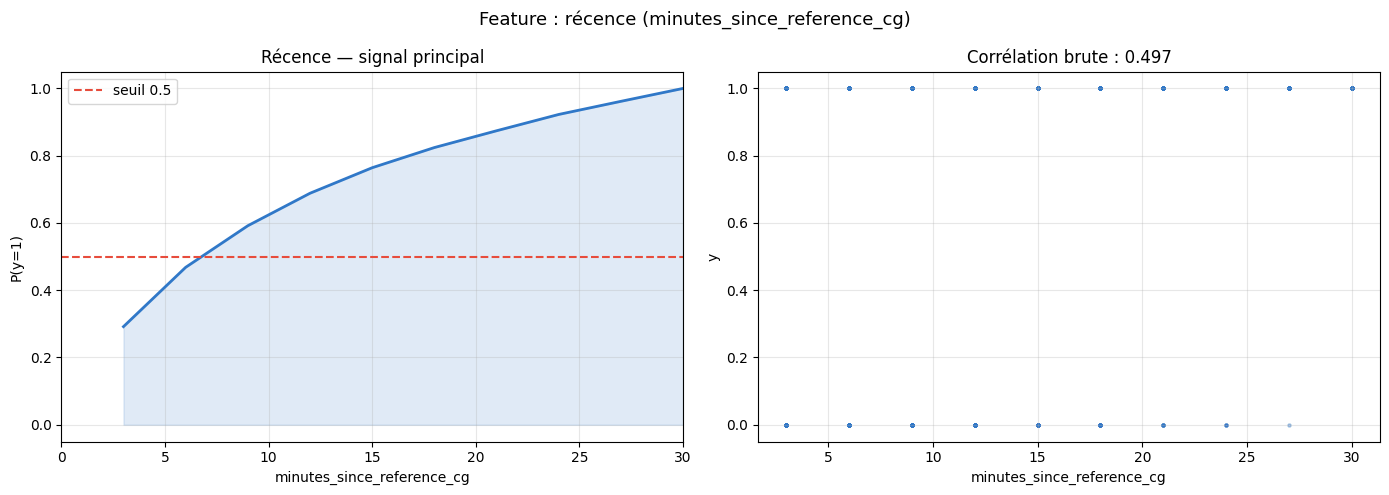

Corrélation minutes_since_reference_cg ↔ y : 0.497

Valeurs disponibles dans curve : [np.int64(3), np.int64(6), np.int64(9), np.int64(12), np.int64(15), np.int64(18), np.int64(21), np.int64(24), np.int64(27), np.int64(30)] ...
P(y=1) à ~ 3 min (valeur réelle=3.0) : 0.292
P(y=1) à ~10 min (valeur réelle=9.0) : 0.592
P(y=1) à ~20 min (valeur réelle=21.0) : 0.874
P(y=1) à ~30 min (valeur réelle=30.0) : 1.000


In [83]:
# Chunk 66 — Récence : signal de minutes_since_reference_cg
curve = (
    df_silence.groupby("min_since_cg")["y"]
    .agg(["mean","count"]).reset_index()
    .rename(columns={"mean":"p_y1","count":"n"})
)
curve = curve[curve["n"] >= 50]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(curve["min_since_cg"], curve["p_y1"], color="#3078c8", linewidth=2)
axes[0].axhline(0.5, color="#e74c3c", linestyle="--", label="seuil 0.5")
axes[0].fill_between(curve["min_since_cg"], curve["p_y1"], alpha=0.15, color="#3078c8")
axes[0].set_xlabel("minutes_since_reference_cg"); axes[0].set_ylabel("P(y=1)")
axes[0].set_title("Récence — signal principal"); axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_xlim(0,30)

corr = df_silence["min_since_cg"].corr(df_silence["y"])
axes[1].scatter(df_silence["min_since_cg"].sample(5000, random_state=42),
                df_silence["y"].sample(5000, random_state=42),
                alpha=0.05, s=5, color="#3078c8")
axes[1].set_xlabel("minutes_since_reference_cg"); axes[1].set_ylabel("y")
axes[1].set_title(f"Corrélation brute : {corr:.3f}"); axes[1].grid(alpha=0.3)
plt.suptitle("Feature : récence (minutes_since_reference_cg)", fontsize=13)
plt.tight_layout(); plt.show()

print(f"Corrélation minutes_since_reference_cg ↔ y : {corr:.3f}")
print(f"\nValeurs disponibles dans curve : {sorted(curve['min_since_cg'].unique())[:10]} ...")

def p_at(t):
    row = curve.iloc[(curve["min_since_cg"] - t).abs().argsort().iloc[0]]
    return row["p_y1"], row["min_since_cg"]

for t in [3, 10, 20, 30]:
    val, actual = p_at(t)
    print(f"P(y=1) à ~{t:2d} min (valeur réelle={actual}) : {val:.3f}")

KeyError: 'n_lre'

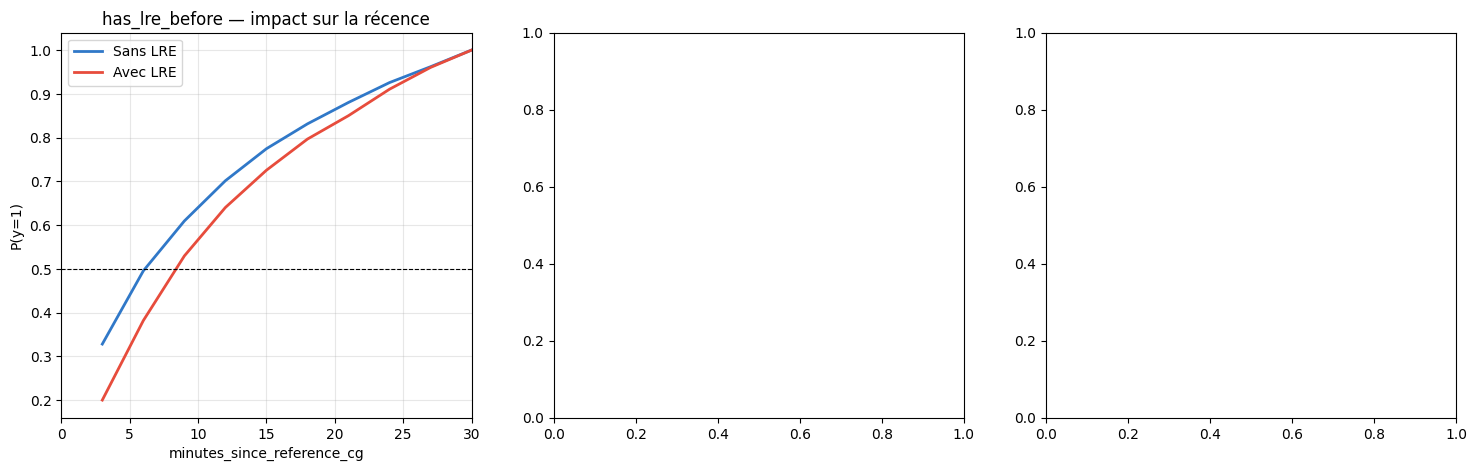

In [84]:
# Chunk 67 — LRE : signal de has_lre_before et time_since_last_lre_min
# Justification : un éclair à moins de 3km est un signal de danger extrême.
# Sa présence passée ralentit la montée de P(y=1), donc retarde la levée.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Signal has_lre_before
for val, label, color in [(0,"Sans LRE","#3078c8"),(1,"Avec LRE","#e74c3c")]:
    sub = df_silence[df_silence["has_lre_before"] == val]
    c = (sub.groupby("min_since_cg")["y"].agg(["mean","count"]).reset_index()
         .rename(columns={"mean":"p_y1","count":"n"}))
    c = c[c["n"] >= 30]
    axes[0].plot(c["min_since_cg"], c["p_y1"], label=label, color=color, linewidth=2)
axes[0].axhline(0.5, color="black", linestyle="--", linewidth=0.8)
axes[0].set_xlim(0,30); axes[0].set_xlabel("minutes_since_reference_cg")
axes[0].set_ylabel("P(y=1)"); axes[0].set_title("has_lre_before — impact sur la récence")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Signal n_lre (nb total de LRE dans l'historique)
lre_bins = [0, 1, 3, 10, np.inf]
lre_labels = ["0","1","2-3","4+"]
df_silence["n_lre_bin"] = pd.cut(df_silence["n_lre"], bins=lre_bins, labels=lre_labels, include_lowest=True)
lre_signal = df_silence.groupby("n_lre_bin")["y"].agg(["mean","count"]).reset_index()
axes[1].bar(lre_signal["n_lre_bin"].astype(str), lre_signal["mean"],
            color="#e74c3c", alpha=0.8, edgecolor="white")
axes[1].set_xlabel("n_lre (nb LRE dans l'historique)"); axes[1].set_ylabel("P(y=1) moyen")
axes[1].set_title("n_lre — plus il y en a, plus l'alerte résiste"); axes[1].grid(alpha=0.3, axis="y")
for i, row in lre_signal.iterrows():
    axes[1].text(i, row["mean"]+0.01, f"n={int(row['count'])}", ha="center", fontsize=8)

# Signal n_lt_3km_last_10m
n3_signal = df_silence.groupby("n_lt_3km_last_10m")["y"].agg(["mean","count"]).reset_index()
n3_signal = n3_signal[n3_signal["count"] >= 20]
axes[2].bar(n3_signal["n_lt_3km_last_10m"].astype(str), n3_signal["mean"],
            color="#f39c12", alpha=0.8, edgecolor="white")
axes[2].set_xlabel("n_lt_3km_last_10m"); axes[2].set_ylabel("P(y=1) moyen")
axes[2].set_title("LRE dans les 10 dernières min — signal fort"); axes[2].grid(alpha=0.3, axis="y")

plt.suptitle("Features LRE — signal sur P(y=1)", fontsize=13)
plt.tight_layout(); plt.show()

print("P(y=1) moyen selon has_lre_before :")
print(df_silence.groupby("has_lre_before")["y"].agg(["mean","count"]).round(3))

/tmp/ipykernel_1077518/3150905449.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lre_signal = df_silence.groupby("n_lre_bin")["y"].agg(["mean","count"]).reset_index()


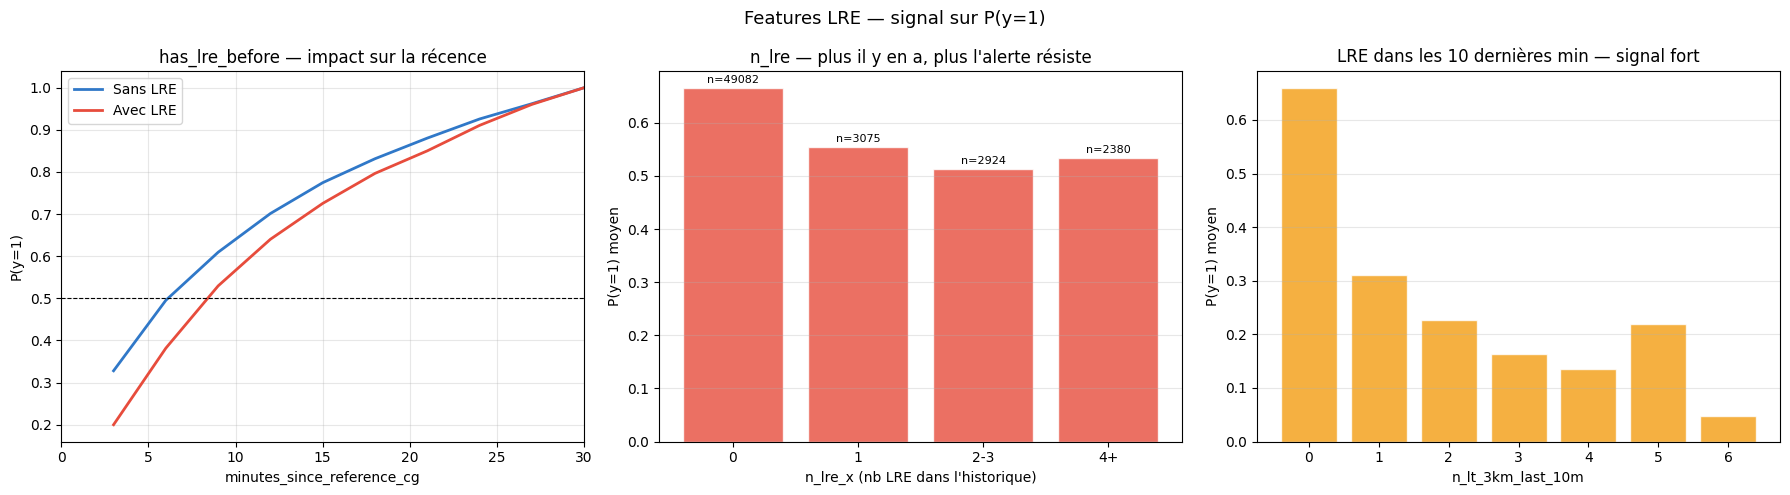

P(y=1) moyen selon has_lre_before :
                 mean  count
has_lre_before              
0               0.671  44302
1               0.559  13159

P(y=1) moyen selon n_lre_x :
            mean  count
n_lre_bin              
0          0.664  49082
1          0.553   3075
2-3        0.512   2924
4+         0.534   2380


/tmp/ipykernel_1077518/3150905449.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_silence.groupby("n_lre_bin")["y"].agg(["mean","count"]).round(3))


In [86]:
# Chunk 67 — LRE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Signal has_lre_before
for val, label, color in [(0,"Sans LRE","#3078c8"),(1,"Avec LRE","#e74c3c")]:
    sub = df_silence[df_silence["has_lre_before"] == val]
    c = (sub.groupby("min_since_cg")["y"].agg(["mean","count"]).reset_index()
         .rename(columns={"mean":"p_y1","count":"n"}))
    c = c[c["n"] >= 30]
    axes[0].plot(c["min_since_cg"], c["p_y1"], label=label, color=color, linewidth=2)
axes[0].axhline(0.5, color="black", linestyle="--", linewidth=0.8)
axes[0].set_xlim(0,30); axes[0].set_xlabel("minutes_since_reference_cg")
axes[0].set_ylabel("P(y=1)"); axes[0].set_title("has_lre_before — impact sur la récence")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Signal n_lre_x (nb total de LRE dans l'historique)
lre_bins = [0, 1, 3, 10, np.inf]
lre_labels = ["0","1","2-3","4+"]
df_silence["n_lre_bin"] = pd.cut(df_silence["n_lre_x"], bins=lre_bins, labels=lre_labels, include_lowest=True)
lre_signal = df_silence.groupby("n_lre_bin")["y"].agg(["mean","count"]).reset_index()
axes[1].bar(lre_signal["n_lre_bin"].astype(str), lre_signal["mean"],
            color="#e74c3c", alpha=0.8, edgecolor="white")
axes[1].set_xlabel("n_lre_x (nb LRE dans l'historique)"); axes[1].set_ylabel("P(y=1) moyen")
axes[1].set_title("n_lre — plus il y en a, plus l'alerte résiste"); axes[1].grid(alpha=0.3, axis="y")
for i, row in lre_signal.iterrows():
    axes[1].text(i, row["mean"]+0.01, f"n={int(row['count'])}", ha="center", fontsize=8)

# Signal n_lt_3km_last_10m
n3_signal = df_silence.groupby("n_lt_3km_last_10m")["y"].agg(["mean","count"]).reset_index()
n3_signal = n3_signal[n3_signal["count"] >= 20]
axes[2].bar(n3_signal["n_lt_3km_last_10m"].astype(str), n3_signal["mean"],
            color="#f39c12", alpha=0.8, edgecolor="white")
axes[2].set_xlabel("n_lt_3km_last_10m"); axes[2].set_ylabel("P(y=1) moyen")
axes[2].set_title("LRE dans les 10 dernières min — signal fort"); axes[2].grid(alpha=0.3, axis="y")

plt.suptitle("Features LRE — signal sur P(y=1)", fontsize=13)
plt.tight_layout(); plt.show()

print("P(y=1) moyen selon has_lre_before :")
print(df_silence.groupby("has_lre_before")["y"].agg(["mean","count"]).round(3))
print("\nP(y=1) moyen selon n_lre_x :")
print(df_silence.groupby("n_lre_bin")["y"].agg(["mean","count"]).round(3))

/tmp/ipykernel_1077518/702249038.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dm_signal = df_silence.groupby("dist_min_bin")["y"].agg(["mean","count"]).reset_index()
/tmp/ipykernel_1077518/702249038.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dd_signal = df_silence.groupby("delta_bin")["y"].agg(["mean","count"]).reset_index()


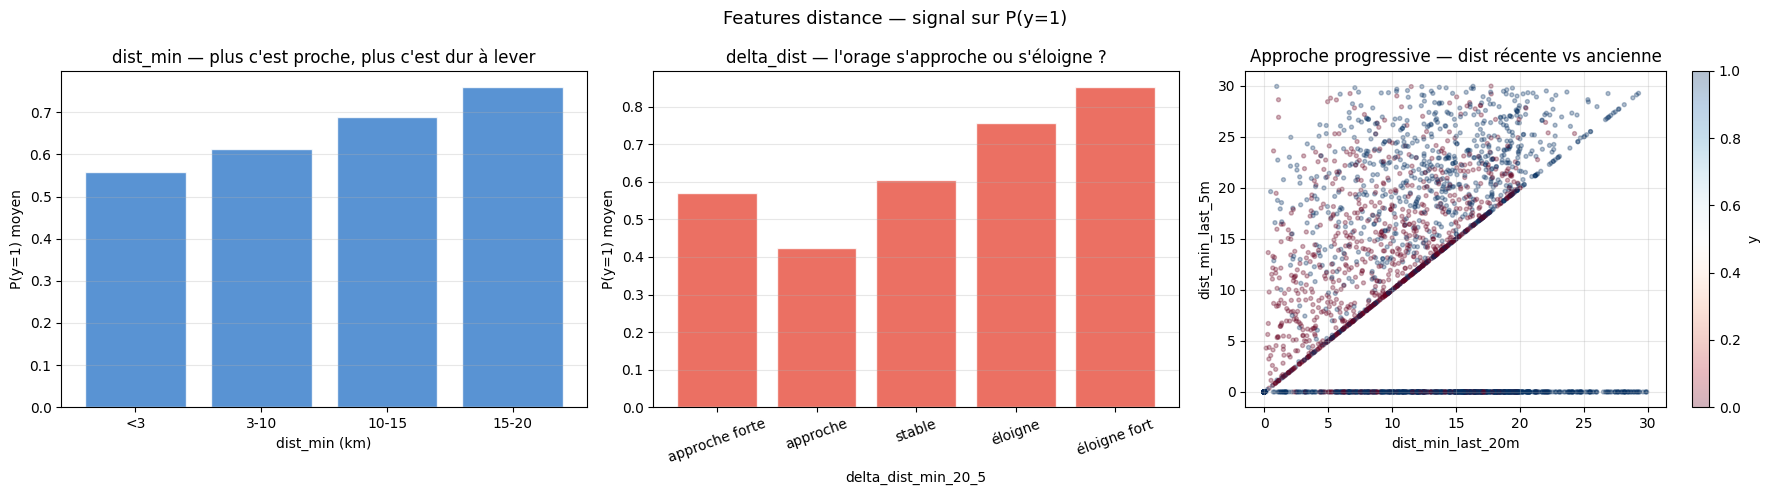

Corrélation dist_min ↔ y        : 0.156
Corrélation delta_dist_min_20_5 : 0.248


In [87]:
# Chunk 68 — Distance : signal de dist_min et delta_dist_min_20_5
# Justification : la distance minimale capte la proximité de l'orage.
# Le delta entre dist_min à 20min et 5min capte si l'orage s'approche ou s'éloigne.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# dist_min en bins
dist_bins  = [0, 3, 10, 15, 20, np.inf]
dist_lbls  = ["<3","3-10","10-15","15-20",">20"]
df_silence["dist_min_bin"] = pd.cut(df_silence["dist_min"], bins=dist_bins,
                                     labels=dist_lbls, include_lowest=True)
dm_signal = df_silence.groupby("dist_min_bin")["y"].agg(["mean","count"]).reset_index()
axes[0].bar(dm_signal["dist_min_bin"].astype(str), dm_signal["mean"],
            color="#3078c8", alpha=0.8, edgecolor="white")
axes[0].set_xlabel("dist_min (km)"); axes[0].set_ylabel("P(y=1) moyen")
axes[0].set_title("dist_min — plus c'est proche, plus c'est dur à lever")
axes[0].grid(alpha=0.3, axis="y")

# delta_dist_min_20_5 : approche vs éloignement
delta_bins  = [-np.inf, -5, -1, 1, 5, np.inf]
delta_lbls  = ["approche forte","approche","stable","éloigne","éloigne fort"]
df_silence["delta_bin"] = pd.cut(df_silence["delta_dist_min_20_5"], bins=delta_bins,
                                  labels=delta_lbls, include_lowest=True)
dd_signal = df_silence.groupby("delta_bin")["y"].agg(["mean","count"]).reset_index()
axes[1].bar(dd_signal["delta_bin"].astype(str), dd_signal["mean"],
            color="#e74c3c", alpha=0.8, edgecolor="white")
axes[1].set_xlabel("delta_dist_min_20_5"); axes[1].set_ylabel("P(y=1) moyen")
axes[1].set_title("delta_dist — l'orage s'approche ou s'éloigne ?")
axes[1].grid(alpha=0.3, axis="y"); axes[1].tick_params(axis='x', rotation=20)

# dist_min_last_5m vs dist_min_last_20m scatter
sample = df_silence.sample(3000, random_state=42)
sc = axes[2].scatter(sample["dist_min_last_20m"], sample["dist_min_last_5m"],
                     c=sample["y"], cmap="RdBu", alpha=0.3, s=8)
plt.colorbar(sc, ax=axes[2], label="y")
axes[2].set_xlabel("dist_min_last_20m"); axes[2].set_ylabel("dist_min_last_5m")
axes[2].set_title("Approche progressive — dist récente vs ancienne")
axes[2].grid(alpha=0.3)

plt.suptitle("Features distance — signal sur P(y=1)", fontsize=13)
plt.tight_layout(); plt.show()

print("Corrélation dist_min ↔ y        :", df_silence["dist_min"].corr(df_silence["y"]).round(3))
print("Corrélation delta_dist_min_20_5 :", df_silence["delta_dist_min_20_5"].corr(df_silence["y"]).round(3))

/tmp/ipykernel_1077518/1644259245.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sig = df_silence.groupby("_tmp")["y"].agg(["mean","count"]).reset_index()
/tmp/ipykernel_1077518/1644259245.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sig = df_silence.groupby("_tmp")["y"].agg(["mean","count"]).reset_index()
/tmp/ipykernel_1077518/1644259245.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sig = df_silenc

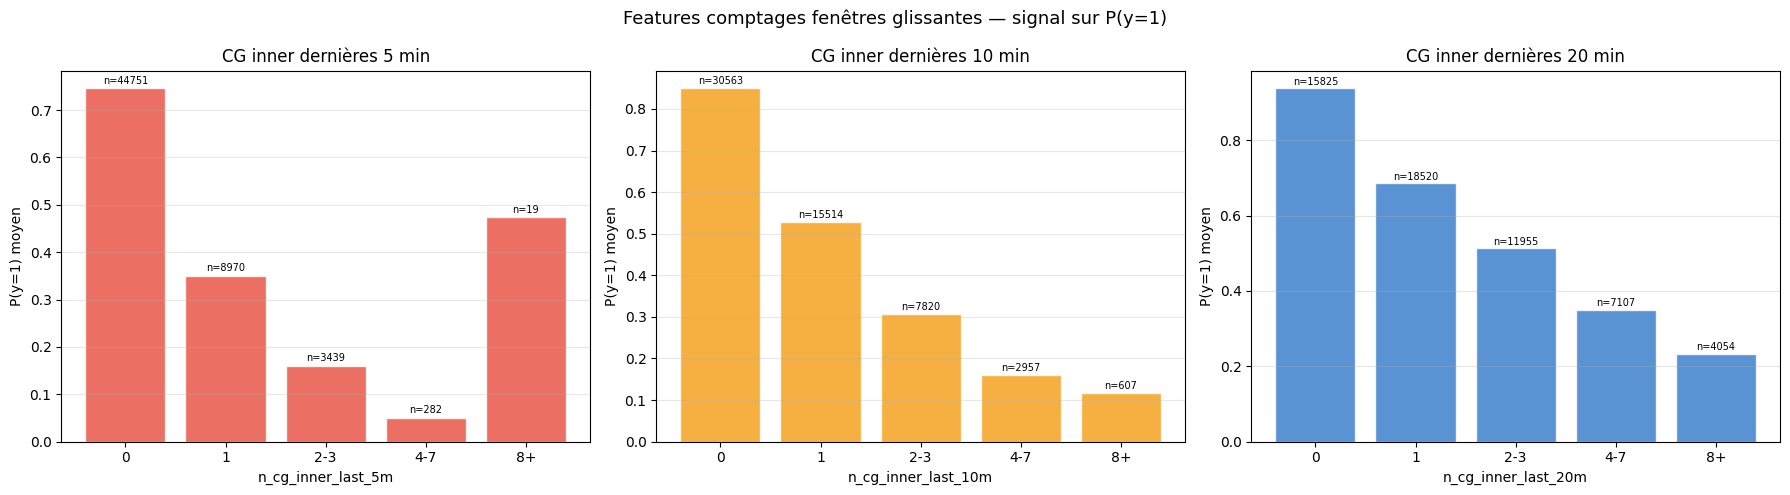

Corrélations ↔ y :
  n_cg_inner_last_5m             : -0.307
  n_cg_inner_last_10m            : -0.340
  n_cg_inner_last_20m            : -0.281
  n_cg_inner                     : -0.064


In [88]:
# Chunk 69 — Comptages par fenêtre glissante : n_cg_inner_last_5m / 10m / 20m
# Justification : l'activité récente en CG inner est un meilleur prédicteur
# que le comptage total — une alerte longue peut avoir beaucoup de CG old.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, w, color in [
    (axes[0], "n_cg_inner_last_5m",  5,  "#e74c3c"),
    (axes[1], "n_cg_inner_last_10m", 10, "#f39c12"),
    (axes[2], "n_cg_inner_last_20m", 20, "#3078c8"),
]:
    bins_n   = [-1, 0, 1, 3, 7, np.inf]
    bins_lbl = ["0","1","2-3","4-7","8+"]
    df_silence["_tmp"] = pd.cut(df_silence[col], bins=bins_n, labels=bins_lbl, include_lowest=True)
    sig = df_silence.groupby("_tmp")["y"].agg(["mean","count"]).reset_index()
    ax.bar(sig["_tmp"].astype(str), sig["mean"], color=color, alpha=0.8, edgecolor="white")
    ax.set_xlabel(f"n_cg_inner_last_{w}m"); ax.set_ylabel("P(y=1) moyen")
    ax.set_title(f"CG inner dernières {w} min"); ax.grid(alpha=0.3, axis="y")
    for i, row in sig.iterrows():
        ax.text(i, row["mean"]+0.01, f"n={int(row['count'])}", ha="center", fontsize=7)

df_silence.drop(columns=["_tmp"], inplace=True)
plt.suptitle("Features comptages fenêtres glissantes — signal sur P(y=1)", fontsize=13)
plt.tight_layout(); plt.show()

print("Corrélations ↔ y :")
for col in ["n_cg_inner_last_5m","n_cg_inner_last_10m","n_cg_inner_last_20m","n_cg_inner"]:
    print(f"  {col:30} : {df_silence[col].corr(df_silence['y']):.3f}")

/tmp/ipykernel_1077518/250954515.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sig = df_silence.groupby("_tmp")["y"].agg(["mean","count"]).reset_index()
/tmp/ipykernel_1077518/250954515.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sig = df_silence.groupby("_tmp")["y"].agg(["mean","count"]).reset_index()
/tmp/ipykernel_1077518/250954515.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sig = df_silence.g

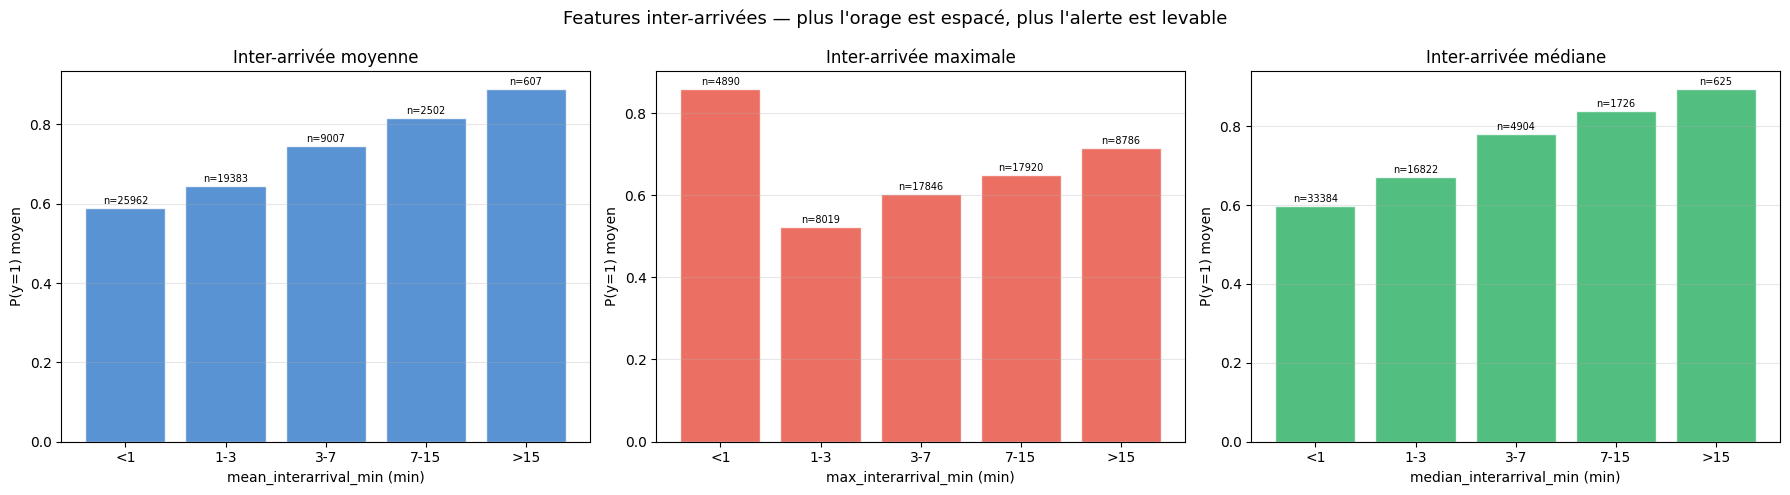

Corrélations ↔ y :
  mean_interarrival_min                         : 0.133
  max_interarrival_min                          : 0.050
  median_interarrival_min                       : 0.127
  current_silence_over_mean_interarrival        : 0.046


In [89]:
# Chunk 70 — Inter-arrivées : mean_interarrival_min et max_interarrival_min
# Justification : si les éclairs arrivent de plus en plus espacés,
# c'est un signe de dissipation de l'orage indépendant de la récence pure.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, color, title in [
    (axes[0], "mean_interarrival_min",   "#3078c8", "Inter-arrivée moyenne"),
    (axes[1], "max_interarrival_min",    "#e74c3c", "Inter-arrivée maximale"),
    (axes[2], "median_interarrival_min", "#27ae60", "Inter-arrivée médiane"),
]:
    bins_i   = [0, 1, 3, 7, 15, np.inf]
    bins_lbl = ["<1","1-3","3-7","7-15",">15"]
    df_silence["_tmp"] = pd.cut(df_silence[col].clip(lower=0), bins=bins_i,
                                 labels=bins_lbl, include_lowest=True)
    sig = df_silence.groupby("_tmp")["y"].agg(["mean","count"]).reset_index()
    ax.bar(sig["_tmp"].astype(str), sig["mean"], color=color, alpha=0.8, edgecolor="white")
    ax.set_xlabel(f"{col} (min)"); ax.set_ylabel("P(y=1) moyen")
    ax.set_title(title); ax.grid(alpha=0.3, axis="y")
    for i, row in sig.iterrows():
        ax.text(i, row["mean"]+0.01, f"n={int(row['count'])}", ha="center", fontsize=7)

df_silence.drop(columns=["_tmp"], inplace=True)
plt.suptitle("Features inter-arrivées — plus l'orage est espacé, plus l'alerte est levable", fontsize=13)
plt.tight_layout(); plt.show()

print("Corrélations ↔ y :")
for col in ["mean_interarrival_min","max_interarrival_min","median_interarrival_min",
            "current_silence_over_mean_interarrival"]:
    print(f"  {col:45} : {df_silence[col].corr(df_silence['y']):.3f}")

/tmp/ipykernel_1077518/1430078221.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sig = df_silence.groupby("_tmp")["y"].agg(["mean","count"]).reset_index()
/tmp/ipykernel_1077518/1430078221.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sig = df_silence.groupby("_tmp")["y"].agg(["mean","count"]).reset_index()
/tmp/ipykernel_1077518/1430078221.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sig = df_silenc

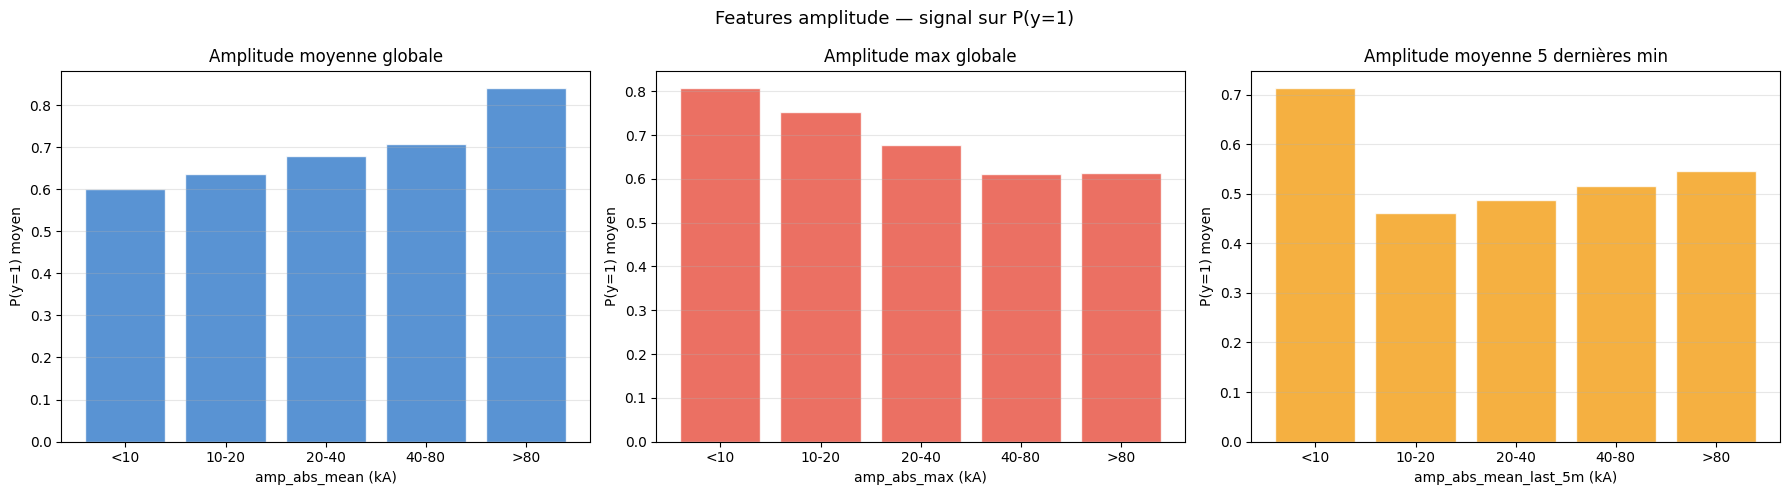

Corrélations ↔ y :
  amp_abs_mean                        : 0.099
  amp_abs_max                         : -0.063
  amp_abs_mean_last_5m                : -0.139
  amp_abs_mean_last_10m               : -0.081


In [90]:
# Chunk 71 — Amplitude : amp_abs_mean et amp_abs_max
# Justification : un orage intense (forte amplitude) est potentiellement
# plus durable. Les éclairs récents de forte amplitude signalent un orage actif.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, color, title in [
    (axes[0], "amp_abs_mean",            "#3078c8", "Amplitude moyenne globale"),
    (axes[1], "amp_abs_max",             "#e74c3c", "Amplitude max globale"),
    (axes[2], "amp_abs_mean_last_5m",    "#f39c12", "Amplitude moyenne 5 dernières min"),
]:
    bins_a   = [0, 10, 20, 40, 80, np.inf]
    bins_lbl = ["<10","10-20","20-40","40-80",">80"]
    df_silence["_tmp"] = pd.cut(df_silence[col].clip(lower=0), bins=bins_a,
                                 labels=bins_lbl, include_lowest=True)
    sig = df_silence.groupby("_tmp")["y"].agg(["mean","count"]).reset_index()
    ax.bar(sig["_tmp"].astype(str), sig["mean"], color=color, alpha=0.8, edgecolor="white")
    ax.set_xlabel(f"{col} (kA)"); ax.set_ylabel("P(y=1) moyen")
    ax.set_title(title); ax.grid(alpha=0.3, axis="y")

df_silence.drop(columns=["_tmp"], inplace=True)
plt.suptitle("Features amplitude — signal sur P(y=1)", fontsize=13)
plt.tight_layout(); plt.show()

print("Corrélations ↔ y :")
for col in ["amp_abs_mean","amp_abs_max","amp_abs_mean_last_5m","amp_abs_mean_last_10m"]:
    print(f"  {col:35} : {df_silence[col].corr(df_silence['y']):.3f}")

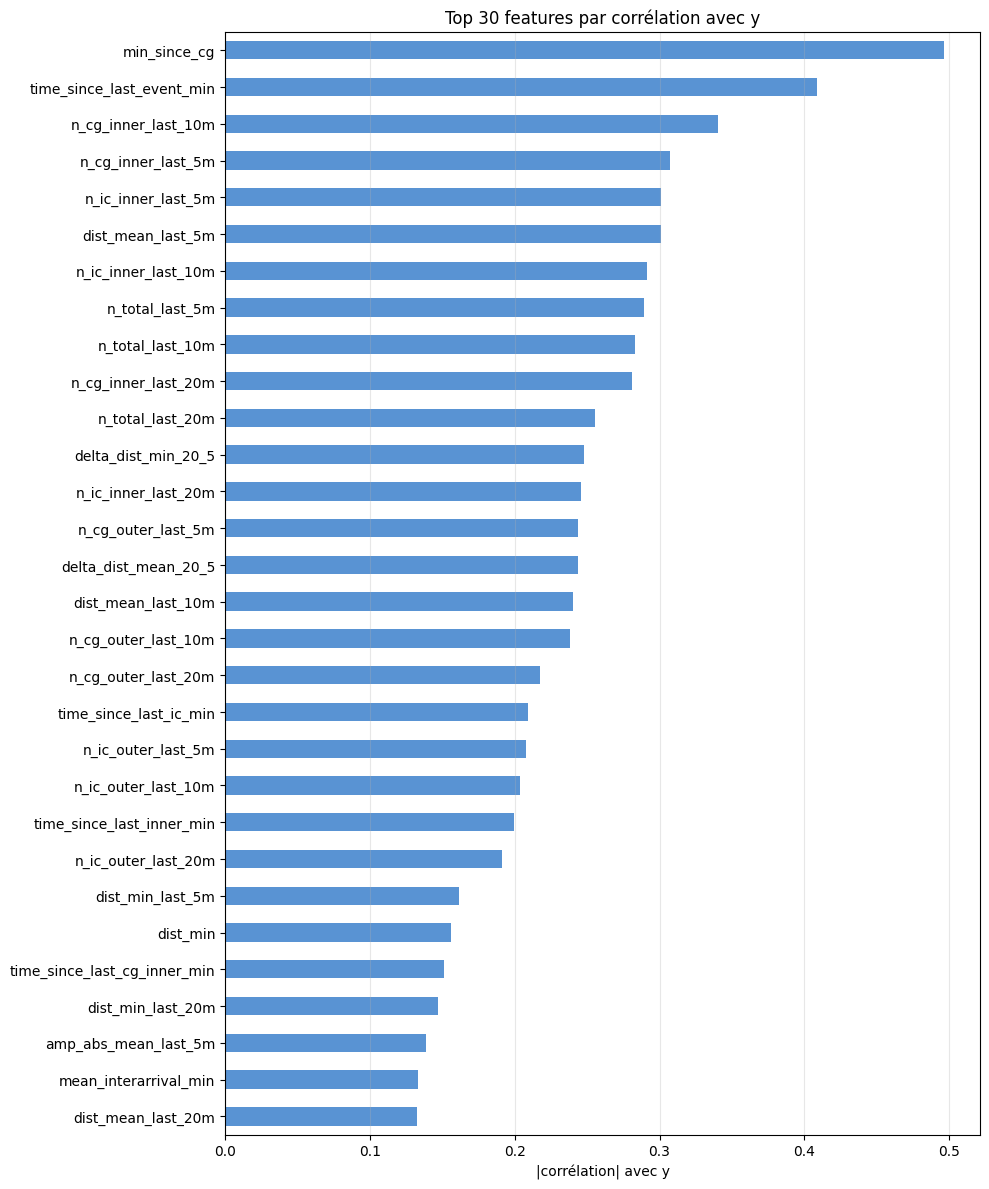

=== Top 15 features par corrélation avec y ===

  min_since_cg                                  : 0.497
  time_since_last_event_min                     : 0.409
  n_cg_inner_last_10m                           : 0.340
  n_cg_inner_last_5m                            : 0.307
  n_ic_inner_last_5m                            : 0.301
  dist_mean_last_5m                             : 0.301
  n_ic_inner_last_10m                           : 0.291
  n_total_last_5m                               : 0.289
  n_total_last_10m                              : 0.283
  n_cg_inner_last_20m                           : 0.281
  n_total_last_20m                              : 0.255
  delta_dist_min_20_5                           : 0.248
  n_ic_inner_last_20m                           : 0.246
  n_cg_outer_last_5m                            : 0.243
  delta_dist_mean_20_5                          : 0.243

=== Catégories de features et leur signal moyen ===

  Récence              : 0.237 (sur 7 features)
  LRE     

In [91]:
# Chunk 72 — Résumé : classement des features par corrélation avec y
# Permet de voir rapidement quelles features portent le plus de signal

feature_excluded = {
    "airport_alert_id","alert_group","obs_start","alert_start",
    "decision_time","cg_reference_index","minutes_since_reference_cg",
    "y","airport","dist_min_bin","delta_bin","n_lre_bin","had_close_cg","has_lre","n_lre_x","n_lre_y"
}
num_cols = [c for c in df_silence.select_dtypes(include=[np.number]).columns
            if c not in feature_excluded]

corrs = (
    pd.Series({c: df_silence[c].corr(df_silence["y"]) for c in num_cols})
    .dropna()
    .abs()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 12))
corrs.head(30).sort_values().plot(kind="barh", ax=ax, color="#3078c8", alpha=0.8)
ax.set_xlabel("|corrélation| avec y"); ax.set_title("Top 30 features par corrélation avec y")
ax.grid(alpha=0.3, axis="x"); plt.tight_layout(); plt.show()

print("=== Top 15 features par corrélation avec y ===\n")
for feat, val in corrs.head(15).items():
    print(f"  {feat:45} : {val:.3f}")

print("\n=== Catégories de features et leur signal moyen ===\n")
categories = {
    "Récence"           : [c for c in corrs.index if "since" in c or "min_since" in c],
    "LRE"               : [c for c in corrs.index if "lre" in c or "lt_3km" in c],
    "Distance"          : [c for c in corrs.index if "dist" in c],
    "Comptages fenêtres": [c for c in corrs.index if "last_" in c and "n_" in c],
    "Inter-arrivées"    : [c for c in corrs.index if "interarrival" in c or "silence_over" in c],
    "Amplitude"         : [c for c in corrs.index if "amp" in c],
}
for cat, feats in categories.items():
    if feats:
        mean_corr = corrs[feats].mean()
        print(f"  {cat:20} : {mean_corr:.3f} (sur {len(feats)} features)")

In [112]:
import pandas as pd
from pathlib import Path

path = Path("../output/silence_dataset.parquet")
print("Chemin :", path.resolve())
print("Existe ?", path.exists())

df_silence = pd.read_parquet(path)

print(df_silence.shape)
print(df_silence.columns.tolist())
df_silence.head()

Chemin : /home/onyxia/work/Dataverse/Dataverse/output/silence_dataset.parquet
Existe ? True
(57461, 73)
['airport', 'airport_alert_id', 'alert_group', 'obs_start', 'alert_start', 'decision_time', 'cg_reference_index', 'minutes_since_reference_cg', 'elapsed_min', 'obs_elapsed_min', 'last_event_type', 'last_event_zone', 'last_event_amplitude', 'last_event_dist', 'n_total', 'n_cg', 'n_ic', 'n_inner', 'n_outer', 'n_cg_inner', 'n_cg_outer', 'n_ic_inner', 'n_ic_outer', 'n_lre', 'amp_abs_mean', 'amp_abs_max', 'dist_mean', 'dist_min', 'time_since_last_event_min', 'time_since_last_cg_min', 'time_since_last_ic_min', 'time_since_last_inner_min', 'time_since_last_cg_inner_min', 'mean_interarrival_min', 'median_interarrival_min', 'max_interarrival_min', 'current_silence_over_mean_interarrival', 'current_silence_over_median_interarrival', 'current_silence_over_max_interarrival', 'n_total_last_5m', 'n_cg_inner_last_5m', 'n_cg_outer_last_5m', 'n_ic_inner_last_5m', 'n_ic_outer_last_5m', 'n_lre_last_5m'

,airport,airport_alert_id,alert_group,obs_start,alert_start,decision_time,cg_reference_index,minutes_since_reference_cg,elapsed_min,obs_elapsed_min,...,dist_mean_last_20m,dist_min_last_20m,amp_abs_mean_last_20m,has_lre_before,time_since_last_lre_min,delta_dist_min_20_5,delta_dist_mean_20_5,n_lt_3km_last_10m,n_lt_3km_last_20m,y
0,Ajaccio,1.0,Ajaccio__1.0,2016-01-02 20:53:53+00:00,2016-01-02 21:22:53+00:00,2016-01-02 21:31:54+00:00,4,3.0,9.017,38.017,...,15.827550,14.313391,12.012857,0,38.017,-1.030,-1.165,0,0,1
1,Ajaccio,1.0,Ajaccio__1.0,2016-01-02 20:53:53+00:00,2016-01-02 21:22:53+00:00,2016-01-02 21:34:54+00:00,4,6.0,12.017,41.017,...,16.329714,14.313391,15.897500,0,41.017,-5.531,-3.515,0,0,1
2,Ajaccio,1.0,Ajaccio__1.0,2016-01-02 20:53:53+00:00,2016-01-02 21:22:53+00:00,2016-01-02 21:37:54+00:00,4,9.0,15.017,44.017,...,17.445994,14.313391,31.838000,0,44.017,-7.392,-4.465,0,0,1
3,Ajaccio,1.0,Ajaccio__1.0,2016-01-02 20:53:53+00:00,2016-01-02 21:22:53+00:00,2016-01-02 21:40:54+00:00,4,12.0,18.017,47.017,...,17.445994,14.313391,31.838000,0,47.017,-7.392,-4.465,0,0,1
4,Ajaccio,1.0,Ajaccio__1.0,2016-01-02 20:53:53+00:00,2016-01-02 21:22:53+00:00,2016-01-02 21:43:54+00:00,4,15.0,21.017,50.017,...,19.124115,15.124224,33.215556,0,50.017,-11.640,-7.640,0,0,1


In [113]:
print("n_lre" in df_silence.columns)
print([c for c in df_silence.columns if "lre" in c.lower()])

True
['n_lre', 'n_lre_last_5m', 'n_lre_last_10m', 'n_lre_last_20m', 'has_lre_before', 'time_since_last_lre_min']


In [114]:
from sklearn.model_selection import GroupShuffleSplit

TARGET_COL = "y"
GROUP_COL = "alert_group"

NON_FEATURE_COLS = {
    "airport_alert_id",
    "alert_group",
    "obs_start",
    "alert_start",
    "decision_time",
    "cg_reference_index",
    "minutes_since_reference_cg",
    "y",
}

feature_cols = [c for c in df_silence.columns if c not in NON_FEATURE_COLS]

X = df_silence[feature_cols].copy()
y = df_silence[TARGET_COL].copy()
groups = df_silence[GROUP_COL].copy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_test = X.iloc[test_idx].copy()
y_test = y.iloc[test_idx].copy()

print(X_test.shape, y_test.shape)

(11823, 65) (11823,)


In [115]:
expected_cols = list(model.feature_names_in_)

missing = sorted(set(expected_cols) - set(X_test.columns))
extra = sorted(set(X_test.columns) - set(expected_cols))

print("Manquantes :", missing)
print("En trop :", extra)

X_test = X_test[expected_cols]

Manquantes : []
En trop : []


In [116]:
import pandas as pd
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std,
}).sort_values("importance_mean", ascending=False)

print(perm_df.head(20))

6606.57s - Error patching args (debugger not attached to subprocess).
Traceback (most recent call last):
  File "/opt/python/lib/python3.13/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_monkey.py", line 541, in patch_args
    new_args.append(_get_python_c_args(host, port, code, unquoted_args, SetupHolder.setup))
                    ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/python/lib/python3.13/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_monkey.py", line 193, in _get_python_c_args
    if "__future__" in code:
       ^^^^^^^^^^^^^^^^^^^^
TypeError: a bytes-like object is required, not 'str'
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: I

                                   feature  importance_mean  importance_std
21               time_since_last_event_min         0.010785        0.000550
42                     n_cg_inner_last_10m         0.010516        0.001177
0                                  airport         0.006365        0.000515
35                      n_ic_inner_last_5m         0.006076        0.000588
25            time_since_last_cg_inner_min         0.004768        0.000540
51                     n_cg_inner_last_20m         0.004755        0.000526
18                             amp_abs_max         0.004455        0.000159
20                                dist_min         0.004381        0.000214
17                            amp_abs_mean         0.004379        0.000356
28                    max_interarrival_min         0.003819        0.000176
32                         n_total_last_5m         0.003818        0.000271
19                               dist_mean         0.003047        0.000149
27          

In [118]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit

TARGET_COL = "y"
GROUP_COL = "alert_group"
AIRPORT_COL = "airport"

NON_FEATURE_COLS = {
    "airport_alert_id",
    "alert_group",
    "obs_start",
    "alert_start",
    "decision_time",
    "cg_reference_index",
    "minutes_since_reference_cg",
    "y",
}

def train_test_split_by_alert(
    df: pd.DataFrame,
    test_size: float = 0.2,
    random_state: int = 42,
):
    train_parts = []
    test_parts = []

    for airport, sub in df.groupby(AIRPORT_COL):
        alert_level = (
            sub.groupby(GROUP_COL, as_index=False)
            .agg(
                airport=(AIRPORT_COL, "first"),
                airport_alert_id=("airport_alert_id", "first"),
                has_lre_alert=("has_lre_before", "max"),
            )
            .copy()
        )

        alert_level["has_lre_alert"] = (
            alert_level["has_lre_alert"].fillna(0).astype(int)
        )

        class_counts = alert_level["has_lre_alert"].value_counts()
        can_stratify = len(class_counts) >= 2 and class_counts.min() >= 2

        if can_stratify:
            sss = StratifiedShuffleSplit(
                n_splits=1, test_size=test_size, random_state=random_state
            )
            idx_train, idx_test = next(
                sss.split(alert_level, alert_level["has_lre_alert"])
            )
        else:
            n_alerts = len(alert_level)
            rng = np.random.RandomState(random_state)
            perm = rng.permutation(n_alerts)
            n_test = max(1, int(round(test_size * n_alerts)))
            idx_test = perm[:n_test]
            idx_train = perm[n_test:]

        train_groups = set(alert_level.iloc[idx_train][GROUP_COL])
        test_groups = set(alert_level.iloc[idx_test][GROUP_COL])

        train_parts.append(sub[sub[GROUP_COL].isin(train_groups)].copy())
        test_parts.append(sub[sub[GROUP_COL].isin(test_groups)].copy())

    train_df = (
        pd.concat(train_parts, axis=0)
        .sort_values([AIRPORT_COL, GROUP_COL, "decision_time"])
        .reset_index(drop=True)
    )

    test_df = (
        pd.concat(test_parts, axis=0)
        .sort_values([AIRPORT_COL, GROUP_COL, "decision_time"])
        .reset_index(drop=True)
    )

    return train_df, test_df


def build_feature_lists(df: pd.DataFrame):
    feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]
    numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]
    categorical_cols = [c for c in feature_cols if c not in numeric_cols]
    return feature_cols, numeric_cols, categorical_cols

In [119]:
import pandas as pd
import joblib
from pathlib import Path
from sklearn.inspection import permutation_importance

# 1) Recharger le dataset propre
df = pd.read_parquet("../output/silence_dataset.parquet")

# 2) Refaire EXACTEMENT ton split officiel
train_df, test_df = train_test_split_by_alert(df, test_size=0.2, random_state=42)

print("Train lignes :", len(train_df), "| alertes :", train_df[GROUP_COL].nunique())
print("Test lignes  :", len(test_df),  "| alertes :", test_df[GROUP_COL].nunique())

# 3) Refaire les mêmes colonnes features que dans ton script
feature_cols, numeric_cols, categorical_cols = build_feature_lists(train_df)

X_test = test_df[feature_cols].copy()
y_test = test_df[TARGET_COL].astype(int).values

print("X_test shape :", X_test.shape)
print("Nb features  :", len(feature_cols))

# 4) Recharger le pipeline sauvegardé
model = joblib.load("../output/model_comparison_with_xgboost/model_xgboost.pkl")
print(type(model))

# 5) Permutation importance sur le VRAI test set
result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc",
    n_jobs=1,   # pour éviter les warnings debugpy
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

print(perm_df.head(20))

Train lignes : 45955 | alertes : 2965
Test lignes  : 11506 | alertes : 743
X_test shape : (11506, 65)
Nb features  : 65
<class 'sklearn.pipeline.Pipeline'>
                                   feature  importance_mean  importance_std
0                      n_cg_inner_last_10m         0.014625        0.000816
1                time_since_last_event_min         0.013486        0.000959
2                       n_ic_inner_last_5m         0.006781        0.000848
3             time_since_last_cg_inner_min         0.005496        0.000452
4                          n_total_last_5m         0.005056        0.000529
5                      n_cg_inner_last_20m         0.004900        0.000446
6   current_silence_over_mean_interarrival         0.002069        0.000344
7                             amp_abs_mean         0.001484        0.000268
8                      n_cg_outer_last_20m         0.001371        0.000225
9                               n_cg_outer         0.001227        0.000232
10      

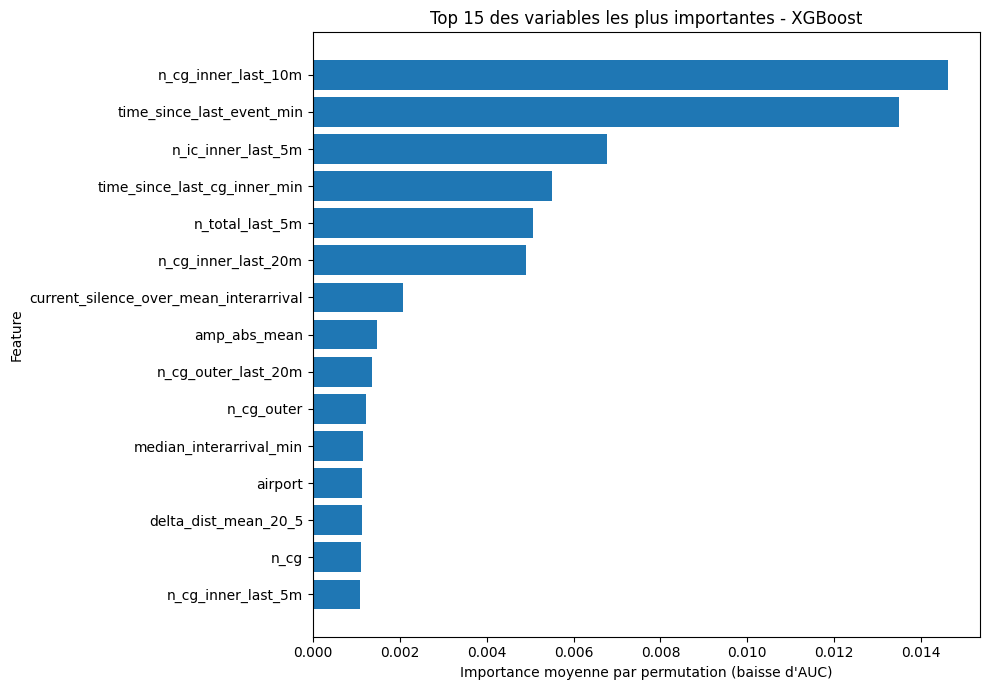

In [120]:
import matplotlib.pyplot as plt

top_n = 15
plot_df = perm_df.head(top_n).sort_values("importance_mean", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.xlabel("Importance moyenne par permutation (baisse d'AUC)")
plt.ylabel("Feature")
plt.title("Top 15 des variables les plus importantes - XGBoost")
plt.tight_layout()
plt.show()

In [122]:
import os
print("Répertoire courant :", os.getcwd())

Répertoire courant : /home/onyxia/work/Dataverse/Dataverse/data


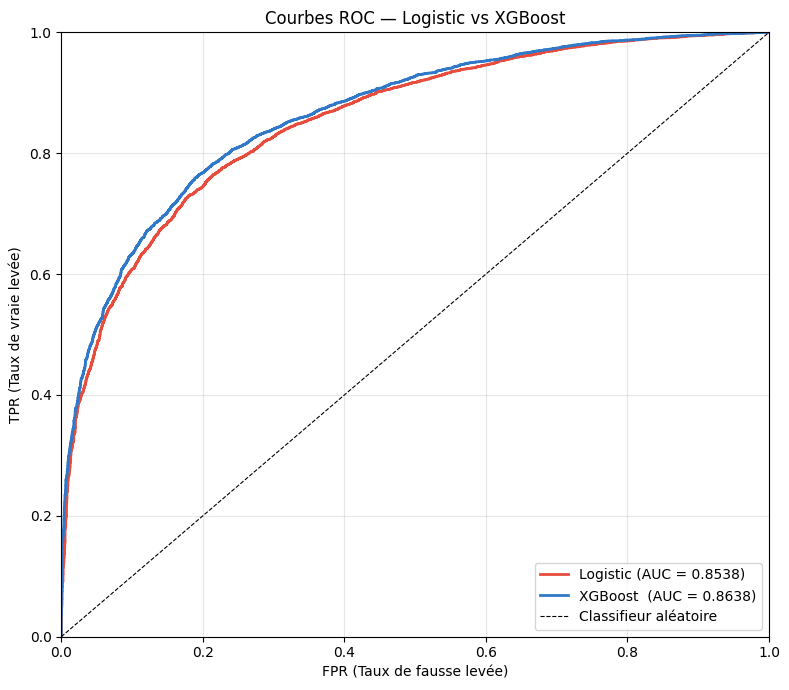

In [123]:
import os
os.chdir("/home/onyxia/work/Dataverse/Dataverse")

import pandas as pd
import matplotlib.pyplot as plt

roc_logistic = pd.read_csv("output/model_comparison_with_logistic/roc_points.csv")
roc_xgboost  = pd.read_csv("output/model_comparison_with_xgboost/roc_points.csv")

metrics_logistic = pd.read_csv("output/model_comparison_with_logistic/test_metrics.csv")
metrics_xgboost  = pd.read_csv("output/model_comparison_with_xgboost/test_metrics.csv")

auc_log = metrics_logistic["auc"].values[0]
auc_xgb = metrics_xgboost["auc"].values[0]

plt.figure(figsize=(8, 7))

plt.plot(roc_logistic["fpr"], roc_logistic["tpr"],
         color="#e74c3c", linewidth=2, label=f"Logistic (AUC = {auc_log:.4f})")

plt.plot(roc_xgboost["fpr"], roc_xgboost["tpr"],
         color="#3078c8", linewidth=2, label=f"XGBoost  (AUC = {auc_xgb:.4f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Classifieur aléatoire")

plt.xlabel("FPR (Taux de fausse levée)")
plt.ylabel("TPR (Taux de vraie levée)")
plt.title("Courbes ROC — Logistic vs XGBoost")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.xlim(0, 1); plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("output/roc_logistic_vs_xgboost.png", dpi=150, bbox_inches="tight")
plt.show()